<div style="border-left: 5px solid #1f4e79; padding: 16px 20px; background-color: #f8fafc; border: 1px solid #d9e2ec; border-radius: 6px; margin-bottom: 24px; font-family: Arial, sans-serif;">  <h1 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 28px;">Notebook 07 — Variables temporelles_B4</h1>  <p style="margin: 0; color: #4b5563; font-size: 15px; line-height: 1.55;">Ce notebook construit la couche temporelle du pipeline immobilier. Il transforme la date de mutation en signaux mensuels exploitables : tendance, volume, volatilité, saisonnalité, phases de marché et variables retardées utilisables en modélisation.</p></div>

In [1]:
# Bloc de traitement du pipeline DVF.
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kruskal
from sklearn.feature_selection import mutual_info_regression

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 120)

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs/temporel_v4"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, bbox_inches="tight")
    plt.show()

print("Racine projet :", PROJECT_ROOT)


Racine projet : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE


In [ ]:
# Chargement du dataset transactionnel enrichi produit par le notebook précédent.
# Ce fichier constitue désormais l'entrée canonique du pipeline de modélisation.

INPUT_PATH = DATA_PROCESSED / "df_biens_residentiels_typologie_marche.parquet"

# Vérification de l'existence du fichier attendu.
if not INPUT_PATH.exists():

    raise FileNotFoundError(
        "Fichier introuvable : "
        "data/processed/df_biens_residentiels_typologie_marche.parquet\n"
        "Exécuter le notebook de typologies de marché avant ce notebook."
    )

# Chargement du dataset principal.
df_raw = pd.read_parquet(INPUT_PATH)

print("Fichier chargé :", INPUT_PATH.name)
print("Shape :", df_raw.shape)

# Harmonisation de la variable prix utilisée par le notebook temporel.
# Les notebooks amont peuvent exporter prix_m2 ou prix_m2_model selon leur rôle dans le pipeline.
if "prix_m2" not in df_raw.columns and "prix_m2_model" in df_raw.columns:
    df_raw["prix_m2"] = df_raw["prix_m2_model"]

required_cols = ["date_mutation", "prix_m2"]
missing_cols = [c for c in required_cols if c not in df_raw.columns]

if missing_cols:
    raise ValueError(f"Colonnes obligatoires absentes : {missing_cols}")

print("Fichier chargé :", source_file.name)
print("Chemin complet :", source_file)
print("Lignes :", f"{len(df_raw):,}")
print("Colonnes :", df_raw.shape[1])

display(df_raw.head(3))


Fichier chargé : df_biens_residentiels_typologie_marche.parquet
Chemin complet : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_typologie_marche.parquet
Lignes : 3,885,803
Colonnes : 160


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,code_commune,nom_commune,code_departement,longitude,latitude,nb_lignes,nb_locaux,nb_appartements,nb_maisons,nb_dependances,surface_bati_totale,surface_terrain_totale,nb_pieces_total,nombre_lots_total,surface_carrez_totale,has_bati,has_terrain,has_imm_special,nb_seg_terrain_a_batir,nb_seg_agricole,nb_seg_agrement,nb_seg_bois_landes,nb_seg_sols,nb_seg_autre,nb_logements,has_logement,has_dependance,mutation_simple_logement,mutation_multiple_logements,ratio_bati_terrain_mutation,type_marche_mutation,type_mutation_economique,avec_dependances,categorie_logement,sous_categorie_logement,type_bien,surface_reference,source_surface_reference,surface_terrain_reference,prix_m2,prix_par_piece,ratio_bati_terrain,flag_valeur_valide,flag_surface_reference_valide,flag_prix_m2_valide,flag_qualite_globale,flag_residentiel,flag_surface_non_positive,flag_valeur_non_positive,flag_prix_m2_non_positif,flag_outlier_valeur_fonciere,flag_outlier_surface_reference,flag_outlier_prix_m2,flag_outlier,prix_m2_recalcule,flag_ecart_prix_m2_10pct,annee_mutation,log_prix_m2,prix_m2_winsor_01_99,log_valeur_fonciere,log_surface_reference,surface_reference_winsor,classe_surface,pieces_info_disponible,surface_par_piece,type_bien_residentiel,is_appartement,is_maison,segment_residentiel_surface,surface_terrain,surface_dependances,terrain_info_disponible,dependance_info_disponible,dependance_surface_info_disponible,ratio_terrain_bati,ratio_dependances_surface,intensite_batie,mois_mutation,trimestre_mutation,annee_mois_mutation,mois_depuis_debut,id_tx_tmp,geometry,code_iris,nom_iris,type_iris,code_commune_tx,code_departement_tx,iris_match_status,nom_iris_territorial,type_iris_territorial,surface_iris_km2,revenu_median,revenu_q1,revenu_q3,indice_inegalite_revenus,taux_pauvrete_60,part_chomage_revenu_disponible,revenu_median_manquant_avant_imputation,revenu_q1_manquant_avant_imputation,revenu_q3_manquant_avant_imputation,indice_inegalite_revenus_manquant_avant_imputation,taux_pauvrete_60_manquant_avant_imputation,part_chomage_revenu_disponible_manquant_avant_imputation,population_2021,taille_menage_moyenne,population_hors_menages,part_population_15_29,part_population_65_plus,nb_logements_2022,part_residences_principales,part_residences_secondaires,part_logements_vacants,part_maisons,part_appartements,nb_equipements_bpe,nb_dpe,score_dpe_moyen,part_dpe_ab,part_dpe_fg,dpe_available,densite_population_km2,densite_logements_km2,iris_code_missing_flag,territorial_match_flag,territorial_unmatched_flag,code_commune_feature_store,code_departement_feature_store,nom_iris_feature_store,nom_commune_feature_store,prix_m2_median,prix_m2_q25,prix_m2_q75,dispersion_prix_relative,transactions_count,transactions_par_mois,signal_marche_fiable,score_liquidite_marche,score_tension_marche,score_premium_marche,score_atypicite_marche,typologie_metier,typologie_metier_code,cluster_kmeans,cluster_kmeans_code,distance_centroid_cluster,pca_1,pca_2,revenu_median_feature_store,nb_logements_feature_store,part_logements_vacants_feature_store,part_residences_principales_feature_store,part_residences_secondaires_feature_store,surface_iris_km2_feature_store,densite_logements_calculee
0,2021-1,2021-01-05,1,Vente,185000.0,01312,PRESSIAT,01,5.386107,46.327101,2,2,0,1,1,97.0,4820.0,5.0,0,NaN,True,1.0,False,0,0,0,0,2,0,1,True,1.0,True,False,0.020124,marche_secondaire_residentiel,maison,True,Maison,Maison moyenne (80-120 m²),Maison,97.00,bati,4820.0,1907.216495,37000.0,0.020124,True,True,True,True,True,False,False,False,False,False,False,False,1907.216495,False,2021,7.553400,1907.216495,12.128111,4.574711,97.00,80-100,1,19.40,maison,0,1,maison_standard,4820.0,NaN,1,1,0,49.690722,NaN,0.020124,1,1,2021-01,0,0,"b""\x01\x01\x00\x00\x00\xd5\x06'\xa2_\x8b\x15@\...",013120000,PRESSIAT,Z,01426,1,within,PRESSIAT,Z,6.018035,22320.0,16275.0,29630.0,0.57,18.5,3.15,True,True,True,True,True,True,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,N

In [ ]:
# Préparationn de la base temporelle
# Bloc de traitement du pipeline DVF.
df = df_raw.copy()

df["date_mutation"] = pd.to_datetime(df["date_mutation"], errors="coerce")
df["prix_m2"] = pd.to_numeric(df["prix_m2"], errors="coerce")

base_time = df.dropna(subset=["date_mutation", "prix_m2"]).copy()
base_time = base_time[base_time["prix_m2"] > 0].copy()

q_low = base_time["prix_m2"].quantile(0.01)
q_high = base_time["prix_m2"].quantile(0.99)

base_time["flag_prix_extreme"] = (
    (base_time["prix_m2"] < q_low) |
    (base_time["prix_m2"] > q_high)
).astype("int8")

base_time = base_time[base_time["flag_prix_extreme"] == 0].copy()

base_time["annee"] = base_time["date_mutation"].dt.year
base_time["mois"] = base_time["date_mutation"].dt.month
base_time["trimestre"] = base_time["date_mutation"].dt.quarter
base_time["annee_mois"] = base_time["date_mutation"].dt.to_period("M").astype(str)

print("Période :", base_time["date_mutation"].min().date(), "->", base_time["date_mutation"].max().date())
print("Lignes temporelles exploitables :", f"{len(base_time):,}")
print("Bornes prix m² conservées :", round(q_low, 0), "->", round(q_high, 0))


Période : 2021-01-01 -> 2025-12-31
Lignes temporelles exploitables : 3,808,088
Bornes prix m² conservées : 410.0 -> 11628.0


In [ ]:
# Contrôle de complétude mensuelles
# Bloc de traitement du pipeline DVF.

# Construction de l’index mensuel théorique couvrant toute la période DVF.
# L’objectif est de vérifier qu’aucun mois n’est manquant dans la série temporelle.
monthly_index = pd.period_range(
    base_time["date_mutation"].min().to_period("M"),  # premier mois observé
    base_time["date_mutation"].max().to_period("M"),  # dernier mois observé
    freq="M"                                          # fréquence mensuelle
).astype(str)

# Liste des mois réellement présents dans les données.
# unique() évite les doublons de transactions.
months_present = set(base_time["annee_mois"].unique())

# Détection des mois absents :
# on compare les mois attendus théoriquement
# avec les mois réellement observés dans le dataset.
months_missing = [m for m in monthly_index if m not in months_present]

# Tableau de synthèse du contrôle de couverture temporelle.
coverage = pd.DataFrame([{
    "mois_attendus": len(monthly_index),   # nombre total de mois théoriques
    "mois_observes": len(months_present),  # mois réellement présents
    "mois_absents": len(months_missing),   # mois manquants détectés
}])

# Affichage du résumé de contrôle.
display(coverage)

# Affichage des premiers mois absents éventuels pour diagnostic.
# Utile pour détecter :
# - une rupture de collecte ;
# - un problème d’import ;
# - ou une anomalie temporelle dans DVF.
print("Mois absents :", months_missing[:20])

,mois_attendus,mois_observes,mois_absents
0,60,60,0


Mois absents : []


In [ ]:
# Construction de la série temporelle
# Bloc de traitement du pipeline DVF.
# Vérification de la présence d’un identifiant unique de mutation.
# Si id_mutation existe, le volume de transactions sera calculé
# à partir du nombre de mutations distinctes.
#
# Sinon, on utilise un simple comptage des lignes prix_m2
# comme approximation du volume transactionnel.
id_col = "id_mutation" if "id_mutation" in base_time.columns else None

# Définition des agrégations mensuelles.
# Les indicateurs calculés permettent de suivre :
# - le niveau de prix ;
# - la dispersion du marché ;
# - l’activité transactionnelle.
agg_dict = {
    "prix_med": ("prix_m2", "median"),                     # prix médian au m²
    "prix_q25": ("prix_m2", lambda s: s.quantile(0.25)),  # premier quartile
    "prix_q75": ("prix_m2", lambda s: s.quantile(0.75)),  # troisième quartile
    "prix_moyen": ("prix_m2", "mean"),                    # prix moyen
}

# Calcul du volume transactionnel.
# nunique() évite de compter plusieurs fois une même mutation.
if id_col:
    agg_dict["volume_tx"] = (id_col, "nunique")
else:
    agg_dict["volume_tx"] = ("prix_m2", "count")

# Agrégation mensuelle des indicateurs.
# Chaque ligne représente ici un mois du marché immobilier.
series_month = (
    base_time.groupby("annee_mois")
    .agg(**agg_dict)
    .reset_index()
)

# Reconstruction d’une vraie variable temporelle.
# Utile pour :
# - les graphiques chronologiques ;
# - les tris temporels ;
# - les modèles de séries temporelles futurs.
series_month["date"] = pd.to_datetime(series_month["annee_mois"] + "-01")

# Tri chronologique explicite.
series_month = series_month.sort_values("date").reset_index(drop=True)

# Création de variables calendaires complémentaires.
# Elles permettront :
# - l’analyse saisonnière ;
# - les regroupements annuels ;
# - les comparaisons trimestrielles.
series_month["annee"] = series_month["date"].dt.year
series_month["mois"] = series_month["date"].dt.month
series_month["trimestre"] = series_month["date"].dt.quarter

# Mesure de dispersion des prix via l’écart interquartile (IQR).
# L’IQR est robuste aux valeurs extrêmes
# et mesure l’écart entre les 25 % et 75 % centraux du marché.
series_month["dispersion_iqr"] = (
    series_month["prix_q75"] - series_month["prix_q25"]
)

# Dispersion relative :
# normalisation de l’IQR par le prix médian.
# Permet de comparer l’hétérogénéité des prix
# entre périodes de niveaux de marché différents.
series_month["dispersion_relative"] = (
    series_month["dispersion_iqr"] / series_month["prix_med"]
)

# Contrôle rapide du résultat.
display(series_month.head())

# Nombre total de mois analysés dans la série temporelle.
print("Nombre de mois analysés :", len(series_month))

,annee_mois,prix_med,prix_q25,prix_q75,prix_moyen,volume_tx,date,annee,mois,trimestre,dispersion_iqr,dispersion_relative
0,2021-01,2289.315155,1449.435823,3542.519452,2794.696554,60960,2021-01-01,2021,1,1,2093.083630,0.914284
1,2021-02,2259.493671,1427.592220,3500.000000,2767.096366,57855,2021-02-01,2021,2,1,2072.407780,0.917200
2,2021-03,2263.917526,1418.367347,3519.069166,2779.490829,68051,2021-03-01,2021,3,1,2100.701819,0.927906
3,2021-04,2250.000000,1419.354839,3481.365079,2744.675367,70125,2021-04-01,2021,4,2,2062.010241,0.916449
4,2021-05,2258.529090,1418.409940,3502.296651,2750.616945,70448,2021-05-01,2021,5,2,2083.886711,0.922674


Nombre de mois analysés : 60


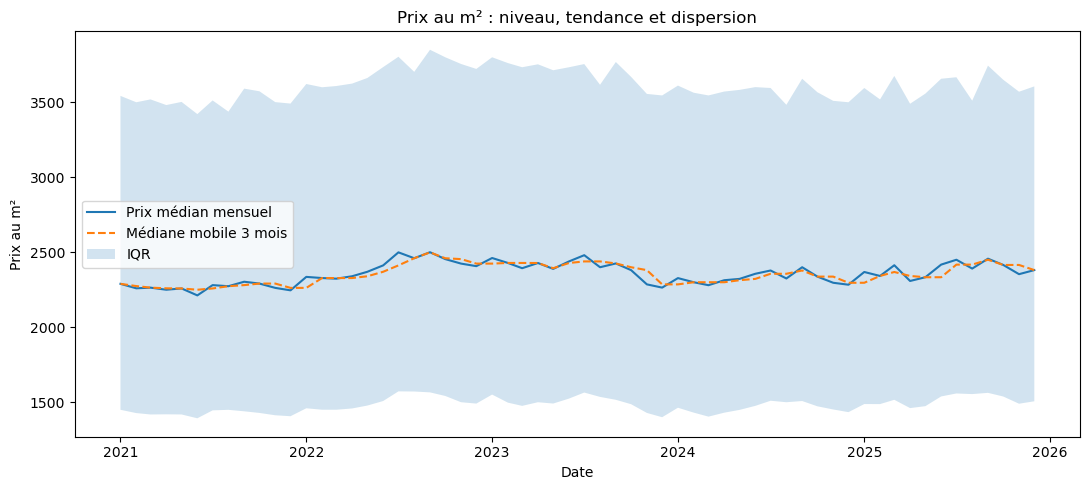

In [ ]:
# Lecture du prix, de sa dispersion et tendance
# Bloc de traitement du pipeline DVF.
# Calcul de tendances mobiles sur le prix médian mensuel.
# L'objectif est de lisser les variations ponctuelles
# afin de mieux visualiser la dynamique générale du marché.

# Médiane mobile sur 3 mois :
# permet de réduire le bruit mensuel tout en conservant une lecture réactive.
series_month["prix_med_roll3"] = (
    series_month["prix_med"]
    .rolling(3, min_periods=1)
    .median()
)

# Médiane mobile sur 6 mois :
# tendance plus lissée, utile pour identifier les mouvements de fond.
# min_periods=2 évite de calculer une tendance trop fragile sur un seul mois.
series_month["prix_med_roll6"] = (
    series_month["prix_med"]
    .rolling(6, min_periods=2)
    .median()
)

# Visualisation du niveau de prix, de la tendance courte
# et de la dispersion interquartile.
plt.figure(figsize=(11, 5))

# Prix médian mensuel observé.
plt.plot(
    series_month["date"],
    series_month["prix_med"],
    label="Prix médian mensuel"
)

# Tendance mobile à 3 mois.
plt.plot(
    series_month["date"],
    series_month["prix_med_roll3"],
    linestyle="--",
    label="Médiane mobile 3 mois"
)

# Bande interquartile :
# zone comprise entre le premier et le troisième quartile.
# Elle donne une lecture de la dispersion des prix autour de la médiane.
plt.fill_between(
    series_month["date"],
    series_month["prix_q25"],
    series_month["prix_q75"],
    alpha=0.2,
    label="IQR"
)

plt.title("Prix au m² : niveau, tendance et dispersion")
plt.xlabel("Date")
plt.ylabel("Prix au m²")
plt.legend()

# Sauvegarde de la figure dans le dossier de sortie du notebook.
save_fig("01_prix_tendance_dispersion.png")

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Analyse de l’évolution du prix au m² : niveau, tendance et dispersion</h3>  <div style="color: #4b5563; font-size: 14px;">Le graphique combine trois lectures complémentaires du marché immobilier : le prix médian mensuel ; une tendance lissée à 3 mois ; la dispersion des prix via l’intervalle interquartile (IQR). Les prix médians restent globalement stables entre 2021 et 2025, avec une légère hausse jusqu’en 2022 puis une phase de stabilisation. Cette évolution est cohérente avec le ralentissement progressif du marché immobilier dans un contexte de hausse des taux d’intérêt et de baisse des volumes de transactions. La médiane mobile confirme l’absence de rupture brutale et met en évidence une dynamique de marché relativement résiliente à l’échelle nationale. L’IQR reste large sur l’ensemble de la période, traduisant une forte hétérogénéité des marchés immobiliers français entre territoires ruraux, métropoles, zones littorales et marchés premium. Cette dispersion demeure relativement stable dans le temps, ce qui suggère une persistance des écarts territoriaux de valorisation. Cette lecture reste toutefois agrégée et masque des disparités locales importantes selon les territoires, les types de biens et les dynamiques régionales.</div></div>

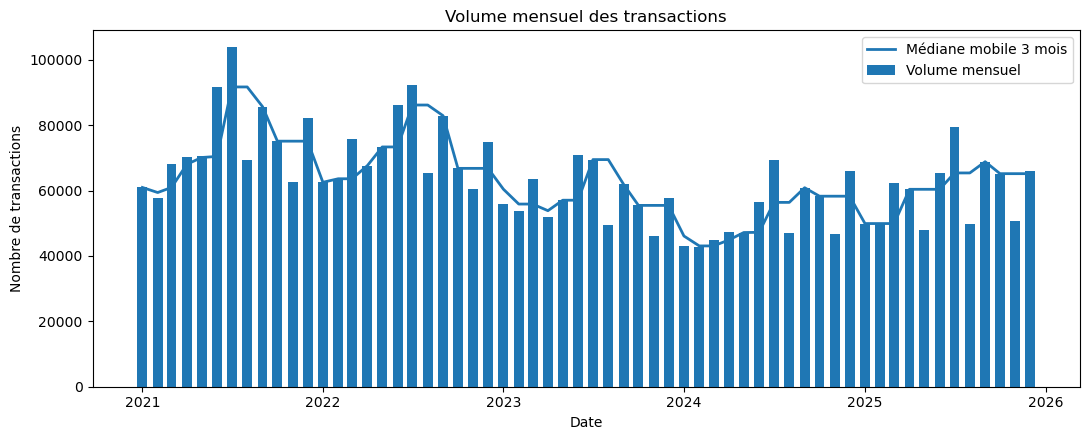

In [ ]:
# Calcul d’une tendance mobile sur le volume de transactions.
# La médiane mobile sur 3 mois permet de lisser :
# - les variations saisonnières ;
# - les pics ponctuels ;
# - les effets calendaires.
#
# La médiane est privilégiée à la moyenne
# car elle est plus robuste aux mois exceptionnellement élevés ou faibles.
series_month["volume_roll3"] = (
    series_month["volume_tx"]
    .rolling(3, min_periods=1)
    .median()
)

# Détection des mois de faible activité transactionnelle.
# Le seuil retenu correspond ici au 10e percentile du volume mensuel.
#
# Les mois situés sous ce seuil reçoivent un indicateur binaire :
# - 1 = faible liquidité ;
# - 0 = activité normale.
#
# Cet indicateur pourra servir plus tard :
# - pour l’analyse des cycles de marché ;
# - la détection de ruptures ;
# - ou certaines segmentations temporelles.
series_month["flag_volume_faible"] = (
    series_month["volume_tx"]
    <= series_month["volume_tx"].quantile(0.10)
).astype("int8")

# Visualisation du volume mensuel brut
# et de sa tendance lissée.
plt.figure(figsize=(11, 4.5))

# Histogramme des transactions mensuelles.
# width contrôle la largeur visuelle des barres sur l’axe temporel.
plt.bar(
    series_month["date"],
    series_month["volume_tx"],
    width=20,
    label="Volume mensuel"
)

# Courbe de tendance mobile.
plt.plot(
    series_month["date"],
    series_month["volume_roll3"],
    linewidth=2,
    label="Médiane mobile 3 mois"
)

plt.title("Volume mensuel des transactions")
plt.xlabel("Date")
plt.ylabel("Nombre de transactions")
plt.legend()

# Sauvegarde automatique de la figure dans le pipeline.
save_fig("02_volume_mensuel.png")


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Analyse du volume mensuel des transactions immobilières</h3>  <div style="color: #4b5563; font-size: 14px;">Le graphique présente l’évolution du volume mensuel de transactions entre 2021 et 2025, complétée par une médiane mobile à 3 mois afin de lisser les variations saisonnières. Le marché conserve un niveau d’activité élevé sur l’ensemble de la période, malgré un ralentissement progressif après les pics observés en 2021–2022. Cette phase correspond au rebond post-Covid et à un contexte de financement encore favorable. À partir de 2022, les volumes diminuent progressivement avant de se stabiliser à un niveau inférieur. Cette évolution est cohérente avec la remontée des taux d’intérêt, le durcissement des conditions de crédit et la baisse de solvabilité des ménages. Le lissage met en évidence une normalisation du marché plutôt qu’un effondrement de l’activité. Quelques reprises ponctuelles restent visibles sur les dernières périodes observées. Le graphique montre également une saisonnalité marquée, avec des volumes généralement plus élevés au printemps et en été, puis un ralentissement en fin d’année. Globalement, le marché apparaît moins dynamique qu’en sortie de crise sanitaire, mais conserve une activité significative. Le ralentissement semble davantage porter sur la liquidité du marché que sur une correction brutale des prix. Cette lecture reste toutefois agrégée et masque des disparités importantes selon les territoires et les segments résidentiels.</div></div>

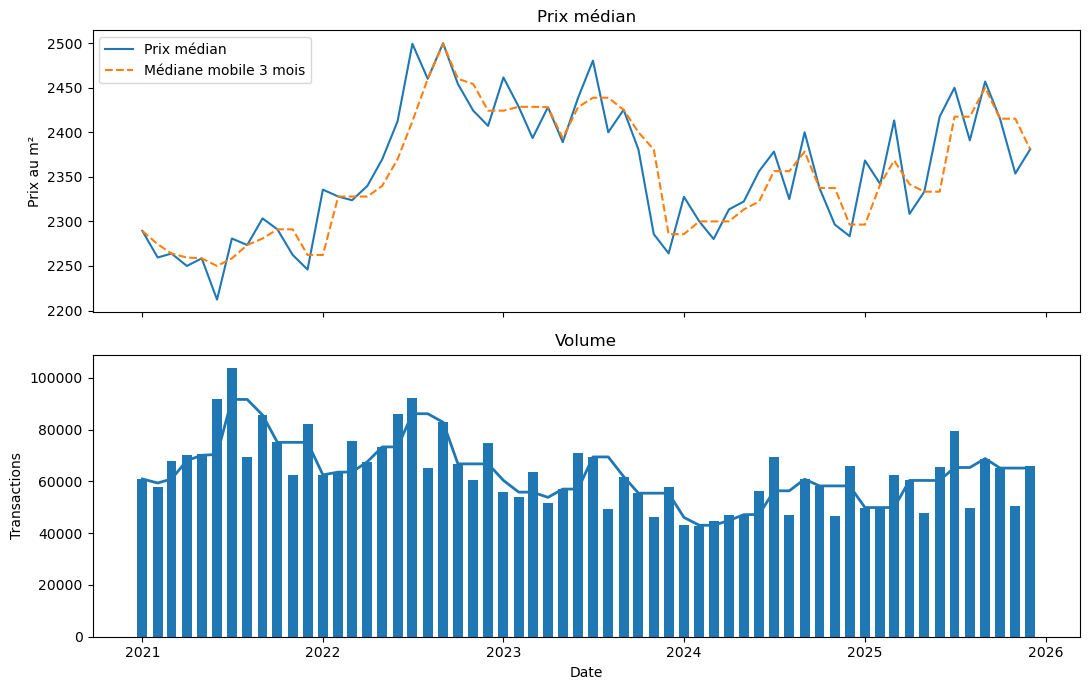

In [ ]:
# Construction d’une figure avec deux graphiques alignés
# pour comparer l’évolution des prix et des volumes.
# Le partage de l’axe X facilite la lecture temporelle.
fig, axes = plt.subplots(
    2, 1,
    figsize=(11, 7),
    sharex=True
)

# Prix médian mensuel au m².
axes[0].plot(
    series_month["date"],
    series_month["prix_med"],
    label="Prix médian"
)

# Tendance lissée sur 3 mois.
# Permet de réduire les fluctuations mensuelles.
axes[0].plot(
    series_month["date"],
    series_month["prix_med_roll3"],
    linestyle="--",
    label="Médiane mobile 3 mois"
)

axes[0].set_title("Prix médian")
axes[0].set_ylabel("Prix au m²")
axes[0].legend()

# Volume mensuel des transactions.
axes[1].bar(
    series_month["date"],
    series_month["volume_tx"],
    width=20
)

# Tendance lissée du volume.
axes[1].plot(
    series_month["date"],
    series_month["volume_roll3"],
    linewidth=2
)

axes[1].set_title("Volume")
axes[1].set_ylabel("Transactions")
axes[1].set_xlabel("Date")

# Sauvegarde de la figure dans le dossier de sortie.
save_fig("03_prix_volume_ensemble.png")

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Analyse conjointe du prix médian et du volume des transactions</h3>  <div style="color: #4b5563; font-size: 14px;">Le graphique rapproche l’évolution des prix immobiliers et celle du volume de transactions afin d’analyser simultanément valorisation et liquidité du marché. La période 2021–2022 se caractérise par une forte activité transactionnelle accompagnée d’une hausse progressive des prix. Ce comportement est cohérent avec le rebond post-Covid et des conditions de financement encore favorables. À partir de 2022–2023, les volumes diminuent nettement tandis que les prix se stabilisent davantage qu’ils ne corrigent. Le marché semble donc s’ajuster principalement par la baisse de la liquidité plutôt que par une chute brutale des valeurs immobilières. Les volumes restent néanmoins significatifs sur l’ensemble de la période et montrent une forme de stabilisation récente, suggérant une phase de normalisation progressive du marché. La volatilité des prix apparaît relativement limitée au regard des variations observées sur les transactions. Ce comportement est classique sur les marchés immobiliers, généralement plus rigides que les marchés financiers. Le graphique met également en évidence une saisonnalité marquée des transactions, avec des pics d’activité plus fréquents au printemps et en été. Globalement, les résultats suggèrent un marché moins dynamique qu’en sortie de crise sanitaire, mais toujours actif et relativement résilient en termes de valorisation agrégée. Cette lecture reste toutefois macroéconomique et masque des disparités importantes selon les territoires et les segments résidentiels.</div></div>

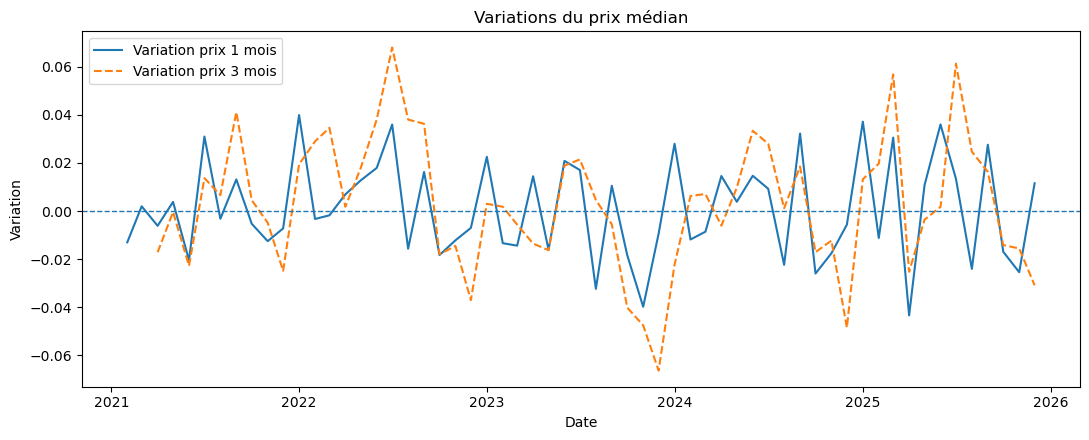

In [ ]:
# Calcul des variations relatives du prix médian et du volume de transactions.
# pct_change() mesure ici l’évolution entre deux périodes :
# - positive = hausse ;
# - négative = baisse.

# Variation mensuelle du prix médian.
# Permet de mesurer les mouvements de court terme du marché.
series_month["variation_prix_mom"] = (
    series_month["prix_med"]
    .pct_change()
)

# Variation mensuelle du volume de transactions.
# Sert à suivre l’évolution de la liquidité du marché.
series_month["variation_volume_mom"] = (
    series_month["volume_tx"]
    .pct_change()
)

# Variation glissante sur 3 mois du prix médian.
# Cette mesure est plus stable et moins sensible
# aux fluctuations ponctuelles d’un mois isolé.
series_month["variation_prix_3m"] = (
    series_month["prix_med"]
    .pct_change(3)
)

# Variation glissante sur 3 mois du volume.
# Permet de mieux visualiser les tendances de moyen terme.
series_month["variation_volume_3m"] = (
    series_month["volume_tx"]
    .pct_change(3)
)

# Visualisation des variations de prix.
plt.figure(figsize=(11, 4.5))

# Variation mensuelle brute.
plt.plot(
    series_month["date"],
    series_month["variation_prix_mom"],
    label="Variation prix 1 mois"
)

# Variation sur 3 mois.
# Le lissage réduit le bruit statistique.
plt.plot(
    series_month["date"],
    series_month["variation_prix_3m"],
    label="Variation prix 3 mois",
    linestyle="--"
)

# Ligne de référence à 0 :
# - au-dessus → hausse des prix ;
# - en dessous → baisse des prix.
plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Variations du prix médian")
plt.xlabel("Date")
plt.ylabel("Variation")
plt.legend()

# Sauvegarde automatique de la figure.
save_fig("04_variations_prix.png")

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Analyse des variations du prix immobilier</h3>  <div style="color: #4b5563; font-size: 14px;">Ce graphique représente les variations relatives du prix médian au m² à court et moyen terme. La série mensuelle apparaît volatile, tandis que le lissage sur trois mois met davantage en évidence la tendance de fond. Les variations restent globalement modérées, le plus souvent comprises entre -4 % et +4 %. Le marché montre ainsi une certaine résilience, sans phase prolongée de correction ni accélération haussière durable. À partir de 2023, plusieurs épisodes de baisse plus marqués apparaissent, cohérents avec : la remontée des taux d’intérêt ; le durcissement des conditions de crédit ; et le ralentissement de la demande solvable. Malgré ces ajustements, les replis restent temporaires et le marché conserve une dynamique globalement stable à l’échelle agrégée. Le graphique suggère ainsi une phase de normalisation et de rééquilibrage progressif du marché immobilier, davantage marquée par une baisse de fluidité que par une chute généralisée des prix.</div></div>

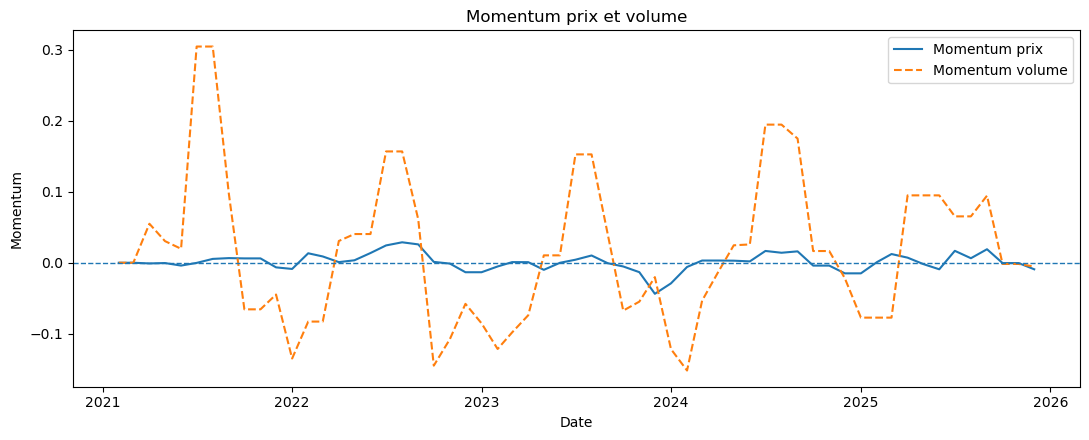

In [ ]:
# Calcul d’un indicateur de momentum sur les prix.
# Le principe consiste à comparer :
# - la tendance courte (3 mois) ;
# - à la tendance plus longue (6 mois).
#
# Un momentum positif signifie que :
# - la dynamique récente est supérieure à la tendance de fond ;
# - le marché accélère.
#
# Un momentum négatif indique au contraire :
# - un ralentissement ;
# - ou une perte de dynamique récente.
series_month["momentum_prix_3_6"] = (
    series_month["prix_med_roll3"] - series_month["prix_med_roll6"]
) / series_month["prix_med_roll6"]

# Même logique appliquée au volume de transactions.
# On compare ici :
# - le volume médian récent sur 3 mois ;
# - à une tendance plus longue sur 6 mois.
#
# Cet indicateur permet de suivre :
# - les accélérations d’activité ;
# - les ralentissements du marché ;
# - les phases de reprise ou de contraction.
series_month["momentum_volume_3_6"] = (
    series_month["volume_roll3"]
    - series_month["volume_tx"].rolling(6, min_periods=2).median()
) / series_month["volume_tx"].rolling(6, min_periods=2).median()

# Visualisation conjointe des momentum prix et volume.
plt.figure(figsize=(11, 4.5))

# Momentum des prix immobiliers.
plt.plot(
    series_month["date"],
    series_month["momentum_prix_3_6"],
    label="Momentum prix"
)

# Momentum des volumes de transactions.
plt.plot(
    series_month["date"],
    series_month["momentum_volume_3_6"],
    label="Momentum volume",
    linestyle="--"
)

# Ligne neutre :
# - au-dessus de 0 → accélération ;
# - en dessous → ralentissement.
plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Momentum prix et volume")
plt.xlabel("Date")
plt.ylabel("Momentum")
plt.legend()

# Sauvegarde automatique de la figure.
save_fig("05_momentum_prix_volume.png")


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Analyse des variations du prix immobilier</h3>  <div style="color: #4b5563; font-size: 14px;">Ce graphique présente les variations relatives du prix médian au m² à court et moyen terme. La série mensuelle apparaît volatile, tandis que le lissage sur trois mois permet de mieux visualiser la tendance sous-jacente. Les variations restent globalement modérées, le plus souvent comprises entre -4 % et +4 %, ce qui traduit un marché relativement résilient malgré des ajustements réguliers. À partir de 2023, plusieurs épisodes de baisse plus marqués apparaissent, cohérents avec : la hausse des taux d’intérêt ; le durcissement des conditions de crédit ; et le ralentissement de la demande solvable. Le marché alterne ainsi des phases courtes de hausse, de correction puis de stabilisation, traduisant une dynamique moins fluide qu’en période post-Covid. Malgré ces tensions, les corrections observées restent temporaires et ne montrent pas de tendance baissière prolongée à l’échelle agrégée. Le graphique suggère davantage une phase de normalisation du marché qu’une rupture immobilière majeure.</div></div>

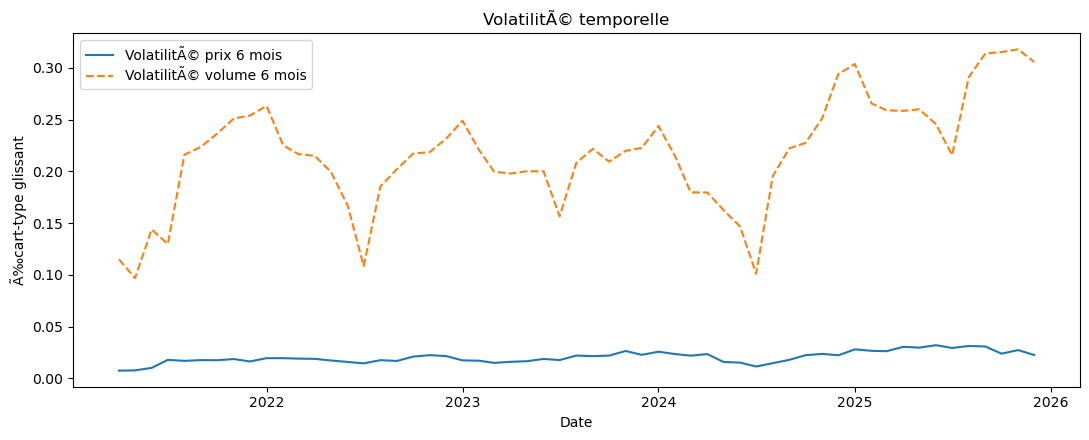

In [ ]:
# Calcul de la volatilité glissante des variations de prix.
# La volatilité correspond ici à l’écart-type des variations mensuelles
# observées sur une fenêtre mobile de 6 mois.
#
# Plus la volatilité est élevée :
# - plus les variations de prix sont instables ;
# - plus le marché évolue de manière irrégulière.
#
# min_periods=3 évite de calculer une volatilité
# sur un historique trop court.
series_month["volatilite_prix_6m"] = (
    series_month["variation_prix_mom"]
    .rolling(6, min_periods=3)
    .std()
)

# Même logique appliquée au volume de transactions.
# Cette mesure permet d’évaluer :
# - la stabilité de la liquidité du marché ;
# - les phases d’accélération ou de contraction brutale.
series_month["volatilite_volume_6m"] = (
    series_month["variation_volume_mom"]
    .rolling(6, min_periods=3)
    .std()
)

# Visualisation des volatilités prix et volume.
plt.figure(figsize=(11, 4.5))

# Volatilité des prix immobiliers.
plt.plot(
    series_month["date"],
    series_month["volatilite_prix_6m"],
    label="Volatilité prix 6 mois"
)

# Volatilité des volumes de transactions.
plt.plot(
    series_month["date"],
    series_month["volatilite_volume_6m"],
    label="Volatilité volume 6 mois",
    linestyle="--"
)

plt.title("Volatilité temporelle")
plt.xlabel("Date")
plt.ylabel("Ecart-type glissant")
plt.legend()

# Sauvegarde automatique de la figure.
save_fig("06_volatilite_temporelle.png")

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Analyse de la volatilité du marché immobilier</h3>  <div style="color: #4b5563; font-size: 14px;">Ce graphique compare la volatilité des prix au m² et celle des volumes de transactions sur une fenêtre glissante de six mois. La volatilité des prix reste globalement faible sur l’ensemble de la période, ce qui confirme la forte inertie du marché immobilier résidentiel. Les ajustements de prix apparaissent progressifs, sans phase de correction brutale à l’échelle agrégée. À l’inverse, les volumes de transactions présentent une volatilité nettement plus élevée et plus irrégulière. L’activité réagit donc plus rapidement aux conditions économiques et financières que les niveaux de prix. À partir de 2024, la volatilité des volumes augmente sensiblement, traduisant un marché : moins fluide ; plus sensible aux conditions de crédit ; et davantage marqué par des comportements d’attente. Cette dissymétrie entre stabilité relative des prix et instabilité de l’activité constitue une caractéristique classique des marchés immobiliers : l’ajustement se fait d’abord par la baisse du nombre de transactions avant une éventuelle correction plus visible des prix. Dans l’ensemble, le graphique suggère une phase de rééquilibrage du marché plutôt qu’une rupture systémique, avec une dégradation progressive de la liquidité mais une relative résilience des valorisations immobilières.</div></div>

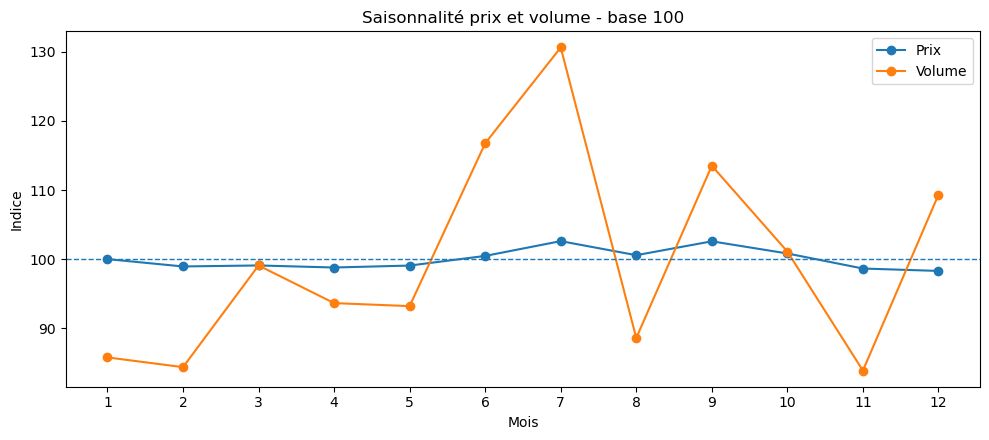

,mois,prix_moyen,volume_moyen,indice_saisonnier_prix,indice_saisonnier_volume
0,1,2356.491037,54463.6,100.012703,85.812513
1,2,2331.549289,53571.0,98.954141,84.406138
2,3,2334.950325,62894.2,99.098485,99.095714
3,4,2327.983465,59444.4,98.802802,93.660231
4,5,2334.587567,59166.8,99.083090,93.222846
5,6,2367.444079,74096.6,100.477565,116.746147
6,7,2417.728538,82883.2,102.611706,130.590259
7,8,2369.891600,56246.4,100.581441,88.621481
8,9,2417.116111,72042.4,102.585714,113.509562
9,10,2375.732189,64170.6,100.829324,101.106802


In [ ]:
# Construction d’un profil saisonnier moyen du marché immobilier.
# L’objectif est d’identifier les mois :
# - historiquement plus actifs ;
# - plus chers ;
# - ou plus faibles en activité.

# Agrégation des indicateurs par mois calendaire.
# Exemple :
# - tous les mois de janvier sont regroupés ;
# - idem pour février, mars, etc.
#
# Cela permet de calculer un comportement "moyen"
# indépendamment de l’année observée.
seasonality = (
    series_month.groupby("mois")
    .agg(
        # Prix médian moyen observé pour chaque mois.
        prix_moyen=("prix_med", "mean"),

        # Volume moyen de transactions par mois.
        volume_moyen=("volume_tx", "mean"),
    )
    .reset_index()
)

# Construction d’un indice saisonnier base 100 pour les prix.
#
# Interprétation :
# - > 100 → mois historiquement plus cher que la moyenne ;
# - < 100 → mois historiquement moins cher.
#
# La normalisation facilite la comparaison entre prix et volume.
seasonality["indice_saisonnier_prix"] = (
    100
    * seasonality["prix_moyen"]
    / seasonality["prix_moyen"].mean()
)

# Même logique appliquée au volume transactionnel.
#
# Exemple :
# un indice de 110 signifie :
# - un volume environ 10 % supérieur à la moyenne annuelle.
seasonality["indice_saisonnier_volume"] = (
    100
    * seasonality["volume_moyen"]
    / seasonality["volume_moyen"].mean()
)

# Visualisation des profils saisonniers.
plt.figure(figsize=(10, 4.5))

# Courbe de saisonnalité des prix.
plt.plot(
    seasonality["mois"],
    seasonality["indice_saisonnier_prix"],
    marker="o",
    label="Prix"
)

# Courbe de saisonnalité des volumes.
plt.plot(
    seasonality["mois"],
    seasonality["indice_saisonnier_volume"],
    marker="o",
    label="Volume"
)

# Ligne de référence base 100 :
# - au-dessus → activité ou prix supérieurs à la moyenne ;
# - en dessous → niveau inférieur à la moyenne.
plt.axhline(
    100,
    linestyle="--",
    linewidth=1
)

plt.title("Saisonnalité prix et volume - base 100")
plt.xlabel("Mois")
plt.ylabel("Indice")

# Affichage explicite des 12 mois.
plt.xticks(range(1, 13))

plt.legend()

# Sauvegarde automatique de la figure.
save_fig("07_saisonnalite_prix_volume.png")

# Affichage du tableau de saisonnalité.
display(seasonality)

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Analyse de la saisonnalité du marché immobilier</h3>  <div style="color: #4b5563; font-size: 14px;">Ce graphique présente les indices saisonniers mensuels des prix au m² et des volumes de transactions, exprimés en base 100. Les prix montrent une saisonnalité relativement faible, avec des variations limitées autour de la moyenne annuelle. Cette stabilité confirme la forte inertie du marché immobilier résidentiel : les ajustements se font peu par les prix à court terme. À l’inverse, les volumes de transactions présentent une saisonnalité marquée. L’activité augmente nettement au printemps et en été, avec un pic observé autour de juillet, tandis que les niveaux les plus faibles apparaissent en début et fin d’année. Cette dynamique reflète des comportements classiques du marché immobilier : concentration des signatures avant l’été ; mobilité résidentielle des ménages ; effets du calendrier scolaire ; et ralentissement hivernal de l’activité. Le contraste entre faible saisonnalité des prix et forte saisonnalité des volumes confirme que le marché ajuste principalement son activité plutôt que ses niveaux de valorisation. Dans l’ensemble, le graphique met en évidence un marché : structurellement saisonnier sur les transactions ; mais beaucoup plus stable sur les prix agrégés.</div></div>

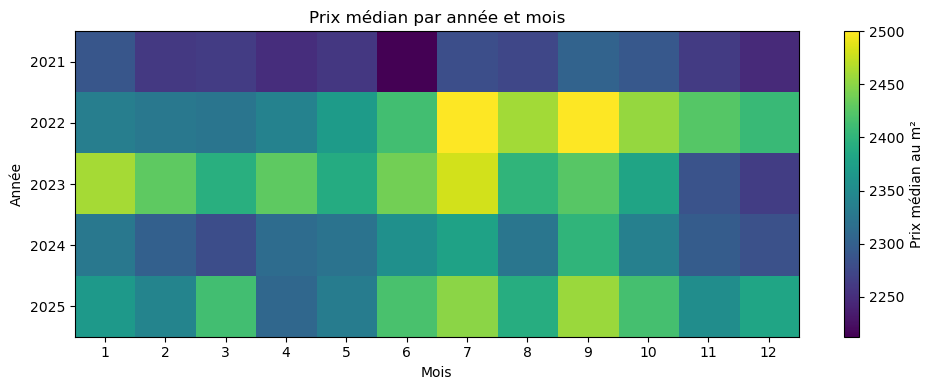

In [ ]:
# Heatmap année_mois
pivot_price = series_month.pivot_table(
    index="annee",
    columns="mois",
    values="prix_med",
    aggfunc="mean"
)

plt.figure(figsize=(10, 4))
plt.imshow(pivot_price, aspect="auto")
plt.colorbar(label="Prix médian au m²")
plt.title("Prix médian par année et mois")
plt.xlabel("Mois")
plt.ylabel("Année")
plt.xticks(range(12), range(1, 13))
plt.yticks(range(len(pivot_price.index)), pivot_price.index)
save_fig("08_heatmap_prix_annee_mois.png")


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Analyse temporelle des prix immobiliers</h3>  <div style="color: #4b5563; font-size: 14px;">Cette carte thermique présente l’évolution du prix médian au m² selon les années et les mois. Les couleurs les plus claires correspondent aux niveaux de prix les plus élevés. La période 2021–2022 se distingue par une hausse généralisée des prix, avec un point haut observé autour de l’été 2022. Cette phase correspond à un marché particulièrement dynamique, soutenu par des conditions de financement encore favorables. À partir de 2023, les niveaux de prix se stabilisent puis amorcent une correction progressive. Les baisses observées restent toutefois modérées et ne traduisent pas de rupture brutale du marché. L’année 2025 montre des signes de stabilisation, avec quelques reprises ponctuelles, mais les niveaux demeurent globalement inférieurs aux sommets atteints en 2022. Une saisonnalité légère reste visible, les prix apparaissant souvent plus élevés durant les périodes estivales. Cependant, les effets macroéconomiques récents — hausse des taux, ralentissement du crédit et baisse de la liquidité — expliquent davantage les variations observées que le seul calendrier annuel. Dans l’ensemble, la heatmap illustre un cycle immobilier récent marqué par : une phase d’expansion jusqu’en 2022 ; un ralentissement progressif à partir de 2023 ; puis une phase de normalisation du marché.</div></div>

In [ ]:
# Encodage cyclique du mois de mutation.
# Les mois sont ici transformés à l’aide de fonctions trigonométriques
# afin de représenter correctement la nature circulaire du calendrier.
#
# Exemple :
# - décembre et janvier sont proches dans le temps ;
# - un simple encodage numérique (1 → 12) ne capture pas cette continuité.
#
# L’encodage sin/cos est particulièrement utile pour :
# - les modèles de machine learning ;
# - les analyses saisonnières ;
# - les modèles temporels.

# Encodage cyclique appliqué à la série mensuelle agrégée.
series_month["mois_sin"] = np.sin(
    2 * np.pi * series_month["mois"] / 12
)

series_month["mois_cos"] = np.cos(
    2 * np.pi * series_month["mois"] / 12
)

# Même transformation appliquée à la base transactionnelle détaillée.
# Cela permettra de réutiliser directement ces variables
# dans les futurs modèles prédictifs.
base_time["mois_sin"] = np.sin(
    2 * np.pi * base_time["mois"] / 12
)

base_time["mois_cos"] = np.cos(
    2 * np.pi * base_time["mois"] / 12
)

# Contrôle des valeurs générées.
# Chaque mois possède désormais :
# - une coordonnée sin ;
# - une coordonnée cos ;
# représentant sa position dans le cycle annuel.
display(
    series_month[
        ["mois", "mois_sin", "mois_cos"]
    ]
    .drop_duplicates()
    .sort_values("mois")
)


,mois,mois_sin,mois_cos
0,1,5.000000e-01,8.660254e-01
1,2,8.660254e-01,5.000000e-01
2,3,1.000000e+00,6.123234e-17
3,4,8.660254e-01,-5.000000e-01
4,5,5.000000e-01,-8.660254e-01
5,6,1.224647e-16,-1.000000e+00
6,7,-5.000000e-01,-8.660254e-01
7,8,-8.660254e-01,-5.000000e-01
8,9,-1.000000e+00,-1.836970e-16
9,10,-8.660254e-01,5.000000e-01


In [ ]:
# Construction d’une typologie simple des phases de marché.
# La logique repose sur l’évolution conjointe :
# - des prix ;
# - et du volume de transactions sur 3 mois.
#
# Chaque mois est classé selon quatre configurations économiques.

conditions = [

    # Prix en hausse + volumes en hausse :
    # marché dynamique avec expansion simultanée
    # des valeurs et de la liquidité.
    (
        (series_month["variation_prix_3m"] > 0)
        & (series_month["variation_volume_3m"] > 0)
    ),

    # Prix en hausse + volumes faibles ou en baisse :
    # marché tendu où les prix résistent malgré
    # une contraction de l’activité.
    (
        (series_month["variation_prix_3m"] > 0)
        & (series_month["variation_volume_3m"] <= 0)
    ),

    # Prix stables ou en baisse + volumes actifs :
    # possible phase de correction ou d’ajustement,
    # avec un marché restant relativement liquide.
    (
        (series_month["variation_prix_3m"] <= 0)
        & (series_month["variation_volume_3m"] > 0)
    ),

    # Prix et volumes en baisse :
    # phase de ralentissement plus généralisé du marché.
    (
        (series_month["variation_prix_3m"] <= 0)
        & (series_month["variation_volume_3m"] <= 0)
    ),
]

# Libellés associés aux différentes phases de marché.
choices = [
    "expansion_prix_volume",
    "tension_prix_volume_faible",
    "correction_volume_actif",
    "ralentissement",
]

# Attribution de la phase correspondante à chaque mois.
# np.select applique les règles définies ci-dessus.
series_month["phase_marche"] = np.select(
    conditions,
    choices,
    default="non_classe"
)

# Comptage du nombre de mois observés dans chaque phase.
phase_counts = (
    series_month["phase_marche"]
    .value_counts()
    .rename_axis("phase_marche")
    .reset_index(name="nb_mois")
)

# Calcul de la part relative de chaque phase dans la période étudiée.
phase_counts["part_pct"] = (
    100
    * phase_counts["nb_mois"]
    / len(series_month)
)

# Affichage de la synthèse des régimes de marché.
display(phase_counts)

,phase_marche,nb_mois,part_pct
0,expansion_prix_volume,17,28.333333
1,ralentissement,17,28.333333
2,tension_prix_volume_faible,15,25.000000
3,correction_volume_actif,8,13.333333
4,non_classe,3,5.000000


In [ ]:
# Construction des scores temporels du marché immobilier.
#
# Objectif :
# Transformer les séries temporelles brutes (prix, volumes, volatilité)
# en indicateurs synthétiques directement exploitables :
#   - analyse économique ;
#   - segmentation des phases de marché ;
#   - scoring de tension ;
#   - variables de modélisation.
#
# Le principe consiste à agréger plusieurs signaux simples :
#   - dynamique des prix ;
#   - dynamique des volumes ;
#   - stabilité ;
#   - liquidité ;
# afin de produire des scores interprétables métier.

# MÉTHODOLOGIE GÉNÉRALE

# Chaque score repose sur :
#   - des règles transparentes ;
#   - des comparaisons relatives ;
#   - ou des seuils statistiques simples.
#
# Les scores sont volontairement :
#   - robustes ;
#   - lisibles ;
#   - non black-box ;
# afin de rester interprétables dans un contexte immobilier.
#
# La logique suivie est proche :
#   - des indicateurs de cycle économique ;
#   - des scores de tension immobilière ;
#   - et des approches de market regime analysis.
#
# Les variables sont ensuite utilisables :
#   - dans les dashboards ;
#   - pour le suivi temporel ;
#   - ou comme features de modèles ML.

# SCORE DE MOMENTUM

# Ce score mesure la dynamique globale du marché.
#
# Trois signaux sont utilisés :
#   1. variation des prix sur 3 mois ;
#   2. momentum prix court terme vs moyen terme ;
#   3. variation récente des volumes.
#
# Chaque signal positif ajoute 1 point.
#
# Interprétation :
#   0 = marché sans dynamique ;
#   1 = légère impulsion ;
#   2 = dynamique positive ;
#   3 = forte accélération du marché.
#
# Le score cherche donc à détecter :
#   - les phases d'expansion ;
#   - les reprises de marché ;
#   - ou les accélérations de cycle.

series_month["score_momentum"] = (
    (series_month["variation_prix_3m"] > 0).astype("int8") +
    (series_month["momentum_prix_3_6"] > 0).astype("int8") +
    (series_month["variation_volume_3m"] > 0).astype("int8")
)

# SCORE DE STABILITÉ
#
# Ce score mesure la stabilité du marché immobilier.
#
# L'indicateur principal utilisé est :
#   - la volatilité glissante des prix sur 6 mois.
#
# Plus la volatilité est faible :
#   -> plus le marché est considéré stable.
#
# Les périodes sont classées en 3 groupes via les quantiles :
#   - tiers le plus stable      -> score 2 ;
#   - tiers intermédiaire       -> score 1 ;
#   - tiers le plus volatile    -> score 0.
#
# Cette approche permet :
#   - d'éviter des seuils arbitraires ;
#   - de s'adapter automatiquement au dataset ;
#   - de conserver une lecture relative du risque.

series_month["score_stabilite"] = np.select(
    [
        series_month["volatilite_prix_6m"] <= series_month["volatilite_prix_6m"].quantile(0.33),
        series_month["volatilite_prix_6m"] <= series_month["volatilite_prix_6m"].quantile(0.66),
    ],
    [2, 1],
    default=0,
)

# SCORE DE LIQUIDITÉ TEMPORELLE

# Ce score mesure l'intensité de l'activité du marché.
#
# Hypothèse métier :
#   un marché liquide présente :
#     - beaucoup de transactions ;
#     - une rotation élevée ;
#     - une meilleure fluidité.
#
# Le score repose donc sur le volume mensuel des transactions.
#
# Classement :
#   volumes élevés        -> score 2 ;
#   volumes intermédiaires -> score 1 ;
#   volumes faibles       -> score 0.
#
# La logique par quantiles permet :
#   - une segmentation robuste ;
#   - indépendante du niveau absolu du marché ;
#   - adaptable aux différentes périodes historiques.

series_month["score_liquidite_temporelle"] = np.select(
    [
        series_month["volume_tx"] >= series_month["volume_tx"].quantile(0.66),
        series_month["volume_tx"] >= series_month["volume_tx"].quantile(0.33),
    ],
    [2, 1],
    default=0,
)

# SCORE DE TENSION TEMPORELLE
#
# Ce score cherche à identifier :
#   des marchés où les prix montent malgré un ralentissement des volumes.
#
# Ce comportement est typique :
#   - d'un déséquilibre offre/demande ;
#   - d'un marché tendu ;
#   - ou d'une raréfaction de l'offre.
#
# Les signaux utilisés :
#   - hausse prix 3 mois ;
#   - momentum prix positif ;
#   - baisse des volumes.
#
# Ici la baisse des volumes est volontairement considérée
# comme un signal positif de tension :
#
#   prix ↑ + volumes ↓
#       = marché sous pression.
#
# Interprétation :
#   score élevé :
#       -> tension immobilière forte ;
#   score faible :
#       -> marché plus détendu.

series_month["score_tension_temporelle"] = (
    (series_month["variation_prix_3m"] > 0).astype("int8") +
    (series_month["momentum_prix_3_6"] > 0).astype("int8") +
    (series_month["variation_volume_3m"] <= 0).astype("int8")
)

# SCORE DE RISQUE TEMPOREL
# Ce score synthétise plusieurs dimensions de fragilité :
#   - instabilité des prix ;
#   - faibles volumes ;
#   - manque de liquidité.
#
# Construction :
#   - on inverse les scores "positifs"
#     (stabilité et liquidité) ;
#   - puis on ajoute un signal de faibles volumes.
#
# Ainsi :
#   marché stable + liquide
#       -> faible risque ;
#
#   marché instable + peu actif
#       -> risque élevé.
#
# Ce score peut servir :
#   - à détecter des zones de stress ;
#   - à qualifier les régimes de marché ;
#   - ou comme feature de modèle prédictif.

series_month["score_risque_temporel"] = (
    (2 - series_month["score_stabilite"]) +
    (2 - series_month["score_liquidite_temporelle"]) +
    series_month["flag_volume_faible"]
)

# LISTE DES SCORES TEMPORELS

# Cette liste facilite :
#   - les exports ;
#   - les visualisations ;
#   - les diagnostics ;
#   - et l'intégration dans les modèles.

score_temporal_cols = [
    "score_momentum",
    "score_stabilite",
    "score_liquidite_temporelle",
    "score_tension_temporelle",
    "score_risque_temporel",
]

# CONTRÔLE FINAL
#
# Affichage des dernières périodes afin de :
#   - vérifier les scores ;
#   - contrôler les phases de marché ;
#   - détecter d'éventuelles anomalies.

display(
    series_month[
        ["annee_mois", "phase_marche"] + score_temporal_cols
    ].tail(12)
)

,annee_mois,phase_marche,score_momentum,score_stabilite,score_liquidite_temporelle,score_tension_temporelle,score_risque_temporel
48,2025-01,tension_prix_volume_faible,1,0,0,2,4
49,2025-02,expansion_prix_volume,3,0,0,2,4
50,2025-03,tension_prix_volume_faible,2,0,1,3,3
51,2025-04,correction_volume_actif,2,0,1,1,3
52,2025-05,ralentissement,0,0,0,1,4
53,2025-06,expansion_prix_volume,2,0,1,1,3
54,2025-07,expansion_prix_volume,3,0,2,2,2
55,2025-08,expansion_prix_volume,3,0,0,2,4
56,2025-09,expansion_prix_volume,3,0,2,2,2
57,2025-10,ralentissement,0,0,1,1,3


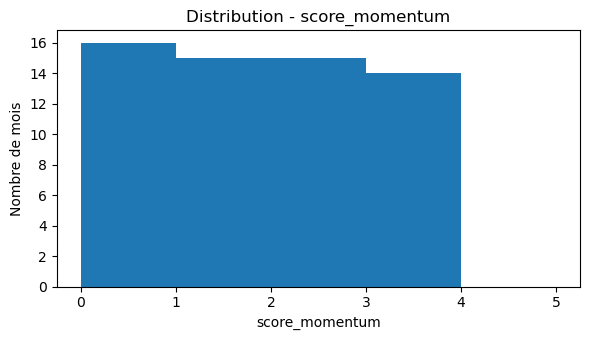

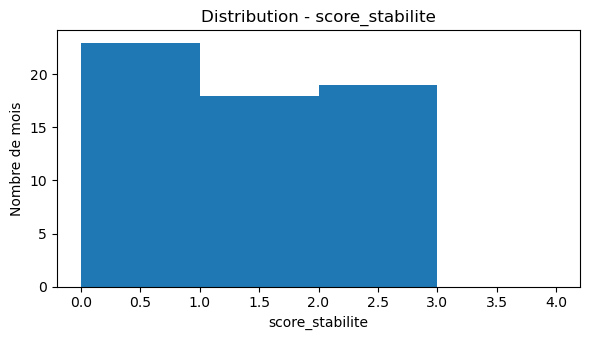

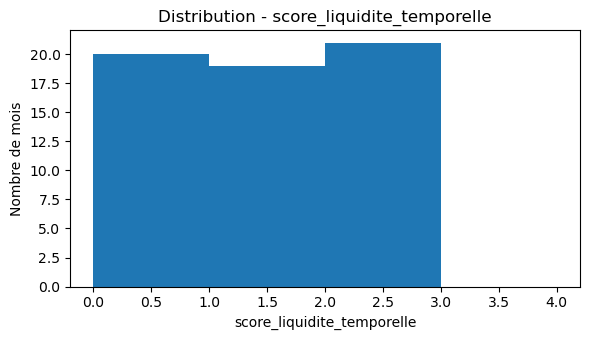

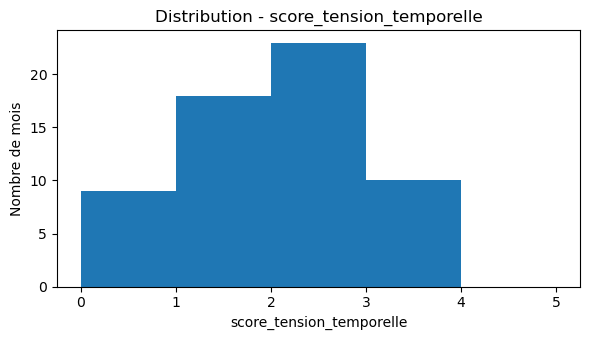

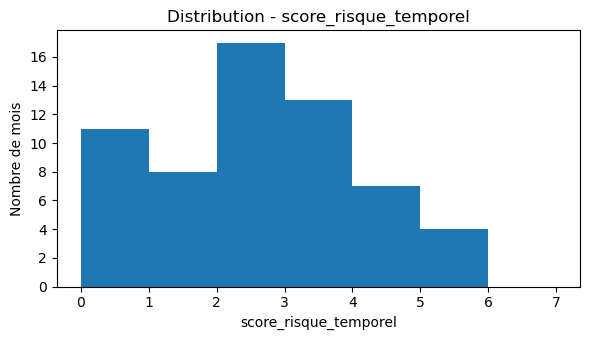

In [ ]:
# Distribution du score
# Bloc de traitement du pipeline DVF.
for col in score_temporal_cols:
    plt.figure(figsize=(6, 3.5))
    plt.hist(series_month[col].dropna(), bins=range(int(series_month[col].max()) + 3))
    plt.title(f"Distribution - {col}")
    plt.xlabel(col)
    plt.ylabel("Nombre de mois")
    save_fig(f"09_distribution_{col}.png")


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Distribution des scores temporels du marché immobilier</h3>  <div style="color: #4b5563; font-size: 14px;">Ces histogrammes présentent la distribution des principaux scores temporels construits dans le pipeline : risque, tension, liquidité, stabilité et momentum. Dans l’ensemble, les distributions restent relativement équilibrées et ne montrent pas de concentration massive sur les niveaux extrêmes. Le marché apparaît ainsi plus instable qu’en phase d’expansion, mais sans signal de rupture systémique durable. Le score de risque se concentre principalement sur des niveaux intermédiaires, traduisant un marché régulièrement sous tension mais rarement en situation critique. Le score de tension confirme une pression immobilière persistante, cohérente avec : des prix relativement résistants ; une offre contrainte ; et une liquidité en baisse depuis 2022. Les scores de liquidité et de stabilité montrent une alternance régulière entre périodes fluides et phases plus hésitantes, reflétant les ajustements progressifs du marché aux nouvelles conditions de financement. Enfin, la distribution du momentum met en évidence des cycles courts de reprise, de ralentissement puis de stabilisation, sans tendance directionnelle forte sur l’ensemble de la période. La cohérence globale entre les différents scores renforce la crédibilité des indicateurs temporels construits dans le pipeline et confirme l’entrée du marché immobilier dans une phase de normalisation plus volatile et moins fluide qu’au sortir de la crise sanitaire.</div></div>

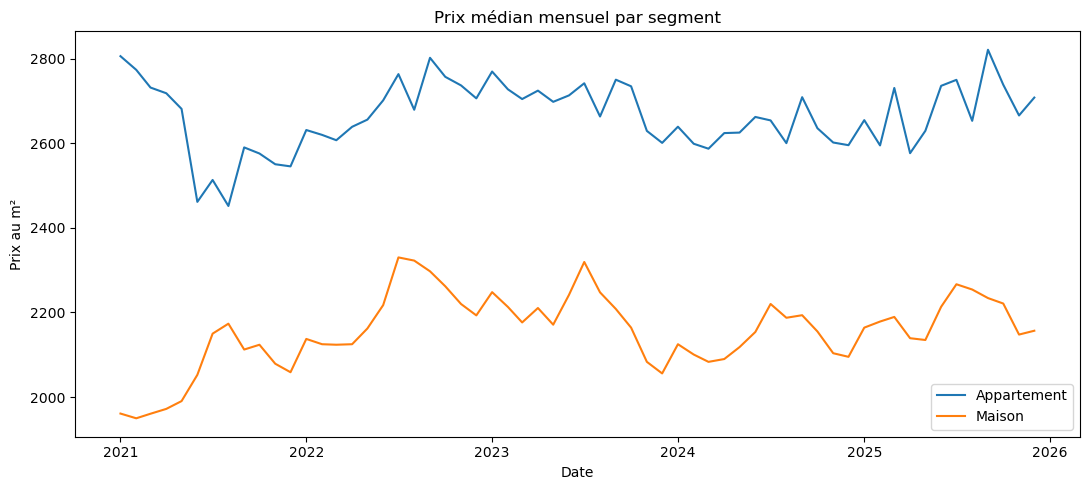

In [ ]:
# Agrégation mensuelle par segment de bien.
# L’objectif est de comparer les dynamiques de prix
# entre les principales catégories du marché résidentiel.

segment_month = pd.DataFrame()

# Sélection de la variable de segmentation disponible.
# On privilégie type_bien si elle existe,
# sinon on utilise type_local.
if "type_bien" in base_time.columns:
    seg_col = "type_bien"
elif "type_local" in base_time.columns:
    seg_col = "type_local"
else:
    seg_col = None

# Si une variable de segment est disponible,
# on calcule les indicateurs mensuels par catégorie.
if seg_col is not None:
    segment_month = (
        base_time.groupby(["annee_mois", seg_col])
        .agg(
            # Prix médian au m² par mois et par segment.
            prix_med=("prix_m2", "median"),

            # Volume de transactions par mois et par segment.
            volume_tx=("prix_m2", "count"),
        )
        .reset_index()
    )

    # Conversion de la période mensuelle en date exploitable pour le graphique.
    segment_month["date"] = pd.to_datetime(
        segment_month["annee_mois"] + "-01"
    )

    # Sélection des segments les plus représentés.
    # Cela évite de surcharger le graphique avec des catégories marginales.
    top_segments = (
        segment_month[seg_col]
        .value_counts()
        .head(4)
        .index
    )

    # Visualisation des prix médians mensuels par segment.
    plt.figure(figsize=(11, 5))

    for seg in top_segments:
        sub = segment_month[segment_month[seg_col] == seg]

        plt.plot(
            sub["date"],
            sub["prix_med"],
            label=str(seg)
        )

    plt.title("Prix médian mensuel par segment")
    plt.xlabel("Date")
    plt.ylabel("Prix au m²")
    plt.legend()

    # Sauvegarde automatique de la figure.
    save_fig("10_prix_mensuel_segments.png")

else:
    # Message de contrôle si aucune variable de segmentation n’est disponible.
    print("Aucune variable de segment disponible.")
    plt.legend()
    save_fig("10_prix_mensuel_segments.png")
else:
    print("Aucune variable de segment disponible.")


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Comparaison temporelle : appartements vs maisons</h3>  <div style="color: #4b5563; font-size: 14px;">Ce graphique compare l’évolution du prix médian au m² des appartements et des maisons sur la période étudiée. Les appartements conservent un niveau de prix structurellement plus élevé, cohérent avec leur forte concentration dans les zones urbaines tendues et les grands bassins d’emploi. Les maisons ont connu une progression plus marquée entre 2021 et 2022, probablement liée aux effets post-Covid : recherche d’espace ; développement du télétravail ; attractivité accrue du résidentiel individuel. À partir de 2023, les deux segments ralentissent, mais les maisons apparaissent plus volatiles et plus sensibles : au durcissement des conditions de financement ; à la baisse de solvabilité des ménages ; et aux arbitrages énergétiques sur le parc ancien. Les appartements montrent une trajectoire plus stable et une meilleure résilience, soutenues par : la tension des marchés urbains ; la rareté foncière ; et une demande locative persistante. Le graphique met ainsi en évidence une différenciation croissante des dynamiques de marché entre habitat collectif et individuel, dans un contexte général de normalisation du cycle immobilier.</div></div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Features temporelles et anti-fuite</h3>  <div style="color: #4b5563; font-size: 14px;">Les variables retardées décrivent l’état du marché connu avant le mois courant. Cette logique est essentielle pour éviter d’utiliser, dans un modèle, une information qui ne serait pas disponible au moment de la prédiction.</div></div>

In [ ]:

# Variables laggées (retardées) :
# ces colonnes représentent l'état du marché au mois précédent.
#
# L'objectif est de construire des variables temporelles exploitables
# dans des modèles prédictifs ou des analyses de dynamique de marché.
#
# Exemple :
# - prix_med_lag1 en mars 2024 = prix médian observé en février 2024.
#
# Cela permet :
# - d'éviter les fuites d'information (data leakage) ;
# - de simuler une vraie situation de prévision ;
# - de mesurer l'influence du passé récent sur le marché actuel.

# Prix médian observé le mois précédent.
# Sert à mesurer l'inertie ou la persistance des prix.
series_month["prix_med_lag1"] = series_month["prix_med"].shift(1)

# Volume de transactions du mois précédent.
# Permet d'étudier l'effet retard du volume sur le marché.
series_month["volume_tx_lag1"] = series_month["volume_tx"].shift(1)

# Variation des prix sur 3 mois, observée au mois précédent.
# Représente la tendance récente des prix connue à t-1.
series_month["variation_prix_3m_lag1"] = (
    series_month["variation_prix_3m"].shift(1)
)

# Variation des volumes sur 3 mois au mois précédent.
# Utile pour détecter les ralentissements ou accélérations du marché.
series_month["variation_volume_3m_lag1"] = (
    series_month["variation_volume_3m"].shift(1)
)

# Momentum prix court vs moyen terme observé au mois précédent.
# Cet indicateur capture l'accélération ou le ralentissement de tendance.
series_month["momentum_prix_3_6_lag1"] = (
    series_month["momentum_prix_3_6"].shift(1)
)

# Volatilité des prix sur fenêtre glissante 6 mois au mois précédent.
# Permet d'intégrer la stabilité ou l'instabilité récente du marché.
series_month["volatilite_prix_6m_lag1"] = (
    series_month["volatilite_prix_6m"].shift(1)
)

# Score agrégé de momentum au mois précédent.
# Résume plusieurs signaux directionnels du marché.
series_month["score_momentum_lag1"] = (
    series_month["score_momentum"].shift(1)
)

# Score de tension du marché observé à t-1.
# Mesure un état de pression du marché juste avant le mois courant.
series_month["score_tension_temporelle_lag1"] = (
    series_month["score_tension_temporelle"].shift(1)
)

# Score de risque observé au mois précédent.
# Sert à évaluer si le marché entrait déjà dans une phase plus fragile.
series_month["score_risque_temporel_lag1"] = (
    series_month["score_risque_temporel"].shift(1)
)

# Affichage de contrôle :
# on vérifie visuellement que les valeurs laggées correspondent bien
# au décalage d'un mois attendu.
display(
    series_month[[
        "annee_mois",
        "prix_med_lag1",
        "volume_tx_lag1",
        "momentum_prix_3_6_lag1",
        "score_momentum_lag1",
        "score_tension_temporelle_lag1",
        "score_risque_temporel_lag1",
    ]].head(12)
)

,annee_mois,prix_med_lag1,volume_tx_lag1,momentum_prix_3_6_lag1,score_momentum_lag1,score_tension_temporelle_lag1,score_risque_temporel_lag1
0,2021-01,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-02,2289.315155,60960.0,NaN,0.0,0.0,3.0
2,2021-03,2259.493671,57855.0,0.000000,0.0,0.0,3.0
3,2021-04,2263.917526,68051.0,0.000000,0.0,0.0,2.0
4,2021-05,2250.000000,70125.0,-0.000978,1.0,0.0,0.0
5,2021-06,2258.529090,70448.0,-0.000427,1.0,0.0,0.0
6,2021-07,2212.224990,91704.0,-0.003989,1.0,0.0,0.0
7,2021-08,2280.808081,103833.0,-0.000213,2.0,1.0,1.0
8,2021-09,2273.480558,69472.0,0.005421,2.0,3.0,0.0
9,2021-10,2303.370787,85678.0,0.006533,2.0,3.0,1.0


In [ ]:
# Bloc de traitement du pipeline DVF.
feature_test = series_month.copy()
feature_test = feature_test.dropna(subset=["prix_med"]).copy()
feature_test["log_prix_med"] = np.log(feature_test["prix_med"])

temporal_candidate_features = [
    "annee",
    "trimestre",
    "mois_sin",
    "mois_cos",
    "volume_tx_lag1",
    "variation_prix_3m_lag1",
    "variation_volume_3m_lag1",
    "momentum_prix_3_6_lag1",
    "volatilite_prix_6m_lag1",
    "score_momentum_lag1",
    "score_tension_temporelle_lag1",
    "score_risque_temporel_lag1",
    "score_stabilite",
    "score_liquidite_temporelle",
]

available_features = [
    c for c in temporal_candidate_features
    if c in feature_test.columns
]

audit_temporal = pd.DataFrame({
    "variable": available_features,
    "pct_manquant": [feature_test[c].isna().mean() for c in available_features],
    "nb_valeurs_distinctes": [feature_test[c].nunique(dropna=True) for c in available_features],
    "variance": [feature_test[c].var() for c in available_features],
    "correlation_log_prix": [feature_test[c].corr(feature_test["log_prix_med"]) for c in available_features],
})

X_mi = feature_test[available_features].copy()
X_mi = X_mi.replace([np.inf, -np.inf], np.nan)
X_mi = X_mi.fillna(X_mi.median(numeric_only=True))

if len(X_mi) >= 5:
    mi_values = mutual_info_regression(X_mi, feature_test["log_prix_med"], random_state=42)
    audit_temporal["information_mutuelle"] = mi_values
else:
    audit_temporal["information_mutuelle"] = np.nan

audit_temporal["decision"] = "à arbitrer"

audit_temporal.loc[
    (audit_temporal["pct_manquant"] <= 0.30) &
    (audit_temporal["nb_valeurs_distinctes"] > 1) &
    (
        (audit_temporal["correlation_log_prix"].abs() >= 0.03) |
        (audit_temporal["information_mutuelle"].fillna(0) > 0)
    ),
    "decision"
] = "conserver"

audit_temporal.loc[
    audit_temporal["variable"].isin([
        "mois_sin",
        "mois_cos",
        "momentum_prix_3_6_lag1",
        "score_momentum_lag1",
        "score_tension_temporelle_lag1",
        "score_risque_temporel_lag1",
    ]),
    "decision"
] = "conserver_métier"

display(audit_temporal.sort_values(["decision", "information_mutuelle"], ascending=[True, False]))


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Analyse des variables temporelles candidates</h3>  <div style="color: #4b5563; font-size: 14px;">Ce tableau évalue les principales variables temporelles selon leur qualité de données, leur stabilité statistique et leur relation avec les prix immobiliers. La qualité globale du jeu de variables est satisfaisante : peu de valeurs manquantes ; bonne diversité des signaux ; variabilité suffisante pour la modélisation. Les variables retardées présentent logiquement quelques valeurs absentes en début de série, liées aux calculs de lags et de fenêtres glissantes, mais les taux restent faibles et acceptables. Les variables les plus informatives sont principalement : les indicateurs de momentum ; les scores de tension ; et les composantes temporelles longues comme l’année. Ces variables captent : les changements de régime du marché ; les dynamiques de prix ; et les effets macroéconomiques récents. Les variables saisonnières (`mois_sin`, `mois_cos`) montrent un apport plus modéré mais restent pertinentes pour intégrer les cycles calendaires dans les futurs modèles. À l’inverse, certaines variables liées uniquement aux volumes présentent une relation plus faible avec les prix. Leur intérêt semble davantage indirect ou dépendant du type de modèle utilisé. Dans l’ensemble, les résultats confirment la cohérence du pipeline temporel : les scores composites apparaissent plus informatifs que les variables brutes ; les signaux de momentum et de tension ressortent clairement ; et la sélection combine de manière pertinente logique statistique et interprétation métier.</div></div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Visualisation du signal des features</h3>  <div style="color: #4b5563; font-size: 14px;">Le graphique d’information mutuelle permet de comparer les variables candidates. Les variables en haut du classement portent davantage de signal statistique sur le prix médian mensuel.</div></div>

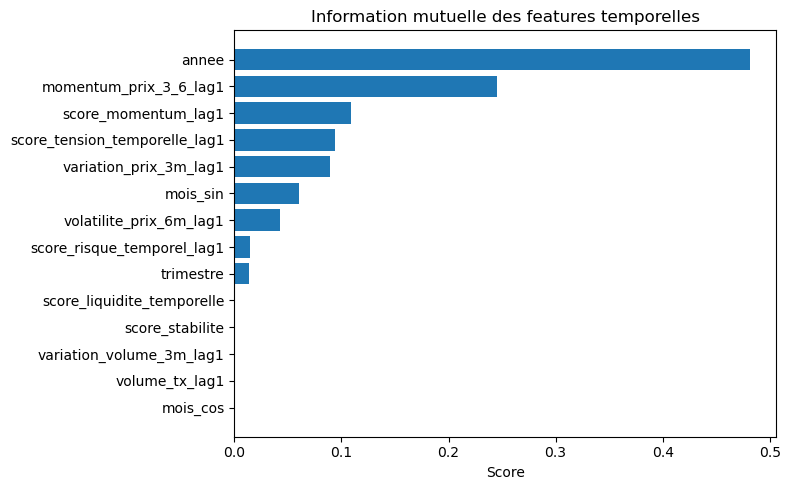

In [ ]:
# Préparation des résultats d’audit des variables temporelles.
# Les lignes sans score d’information mutuelle sont exclues
# afin de conserver uniquement les variables évaluées correctement.
#
# Le tri croissant facilite la lecture comparative
# des variables les moins et les plus informatives.
plot_audit = (
    audit_temporal
    .dropna(subset=["information_mutuelle"])
    .sort_values("information_mutuelle")
)

# Visualisation des scores d’information mutuelle.
# Chaque barre représente le niveau d’information
# apporté par une variable temporelle
# vis-à-vis de la cible étudiée.
plt.figure(figsize=(8, 5))

plt.barh(
    plot_audit["variable"],
    plot_audit["information_mutuelle"]
)

# Plus le score est élevé :
# - plus la variable contient un signal utile ;
# - plus sa relation statistique avec la cible est forte.
#
# L’information mutuelle permet de détecter :
# - des relations linéaires ;
# - mais aussi des dépendances non linéaires.
plt.title("Information mutuelle des features temporelles")

plt.xlabel("Score")

# Sauvegarde automatique de la figure.
save_fig("11_information_mutuelle_features_temporelles.png")

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Analyse des variables temporelles candidates</h3>  <div style="color: #4b5563; font-size: 14px;">Ce tableau évalue les principales variables temporelles selon leur qualité statistique, leur stabilité et leur contribution potentielle à la modélisation des prix immobiliers. La qualité globale des données apparaît satisfaisante : peu de valeurs manquantes ; bonne variabilité des signaux ; et distributions exploitables pour la modélisation. Les variables retardées présentent logiquement quelques valeurs absentes en début de série, liées aux calculs de lags et de fenêtres glissantes, mais ces niveaux restent faibles et compatibles avec une approche temporelle robuste. Les variables les plus informatives sont principalement : les scores de momentum ; les indicateurs de tension ; et les composantes temporelles longues comme l’année. Ces variables captent efficacement : les changements de régime du marché ; les dynamiques de prix ; et les effets macroéconomiques récents. Les variables saisonnières (`mois_sin`, `mois_cos`) montrent un apport plus modéré mais restent pertinentes pour intégrer les cycles calendaires sans rupture artificielle entre les mois. À l’inverse, certaines variables liées uniquement aux volumes présentent une relation plus faible avec les prix. Leur intérêt semble davantage indirect ou dépendant du type de modèle utilisé. Dans l’ensemble, les résultats confirment la cohérence du pipeline temporel : les signaux composites apparaissent plus robustes que les variables brutes ; les effets de momentum et de tension ressortent clairement ; et la sélection combine de manière pertinente logique statistique et interprétation métier.</div></div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Tests de groupes temporels</h3>  <div style="color: #4b5563; font-size: 14px;">Le test de Kruskal-Wallis vérifie si les distributions de prix diffèrent selon les phases de marché et les trimestres. Il ne prouve pas une causalité, mais signale une séparation statistique entre groupes.</div></div>

In [ ]:
# Initialisation de la liste qui stockera
# les résultats des tests statistiques.
kruskal_rows = []

# Test de plusieurs variables temporelles catégorielles.
# Ici :
# - phase_marche ;
# - trimestre.
#
# Le but est de vérifier si les distributions
# de log_prix_med diffèrent significativement
# selon les groupes observés.
for col in ["phase_marche", "trimestre"]:

    # Vérification que la variable existe bien dans le dataset.
    if col in feature_test.columns:

        # Construction des groupes utilisés dans le test.
        # Chaque groupe contient les valeurs de log_prix_med
        # associées à une modalité de la variable.
        #
        # Les groupes trop petits (< 3 observations)
        # sont exclus afin d’éviter des tests instables.
        groups = [
            sub["log_prix_med"].values
            for _, sub in feature_test.groupby(col)
            if len(sub) >= 3
        ]

        # Le test nécessite au minimum deux groupes comparables.
        if len(groups) >= 2:

            # Test non paramétrique de Kruskal-Wallis.
            #
            # Ce test permet de comparer plusieurs distributions
            # sans supposer de normalité des données.
            #
            # Il est adapté ici car :
            # - les prix immobiliers sont souvent asymétriques ;
            # - les variances peuvent différer entre groupes.
            stat, p_value = kruskal(*groups)

            # Stockage des résultats.
            kruskal_rows.append({
                "variable": col,

                # Intensité de la différence observée entre groupes.
                "statistique": stat,

                # Niveau de significativité statistique.
                # Une faible p-value suggère que :
                # les groupes présentent des distributions différentes.
                "p_value": p_value,

                # Nombre de groupes effectivement comparés.
                "nb_groupes": len(groups),
            })

# Conversion des résultats en DataFrame.
kruskal_temporal = pd.DataFrame(kruskal_rows)

# Affichage de la synthèse statistique.
display(kruskal_temporal)

,variable,statistique,p_value,nb_groupes
0,phase_marche,14.541748,0.005752,5
1,trimestre,6.669694,0.083205,4


In [ ]:
# Conservation d’une copie complète de la série temporelle.
# Cette table contient l’ensemble :
# - des indicateurs temporels ;
# - des métriques de marché ;
# - des variables dérivées ;
# - et des diagnostics construits dans le notebook.
temporal_market_full = series_month.copy()

# Sélection des variables destinées au futur pipeline de modélisation.
# L’objectif est de constituer un feature store temporel :
# - compact ;
# - exploitable ;
# - et orienté machine learning.
#
# Les variables retenues incluent :
# - composantes calendaires ;
# - effets saisonniers ;
# - indicateurs retardés (lag) ;
# - momentum ;
# - volatilité ;
# - scores composites.
model_feature_cols = [
    "annee_mois",
    "annee",
    "trimestre",
    "mois_sin",
    "mois_cos",
    "prix_med_lag1",
    "volume_tx_lag1",
    "variation_prix_3m_lag1",
    "variation_volume_3m_lag1",
    "momentum_prix_3_6_lag1",
    "volatilite_prix_6m_lag1",
    "score_momentum_lag1",
    "score_tension_temporelle_lag1",
    "score_risque_temporel_lag1",
]

# Filtrage de sécurité.
# Permet d’éviter les erreurs si certaines variables
# ne sont pas présentes dans la version courante du pipeline.
model_feature_cols = [
    c for c in model_feature_cols
    if c in series_month.columns
]

# Construction du sous-ensemble réellement destiné à la modélisation.
temporal_features_model = (
    series_month[model_feature_cols]
    .copy()
)

# Export de la série temporelle complète au format parquet.
# Ce format est optimisé pour :
# - les gros volumes ;
# - la rapidité de lecture ;
# - et les futurs pipelines analytiques.
temporal_market_full.to_parquet(
    TABLE_DIR / "temporal_market_full_v4.parquet",
    index=False
)

# Export du feature store temporel destiné à la modélisation.
# Cette version est plus légère et centrée
# sur les variables explicatives temporelles.
temporal_features_model.to_parquet(
    TABLE_DIR / "temporal_features_model_v4.parquet",
    index=False
)

# Export des indicateurs de saisonnalité.
# Permet de réutiliser les profils saisonniers
# dans des analyses ou dashboards externes.
seasonality.to_csv(
    TABLE_DIR / "temporal_saisonnalite_v4.csv",
    index=False
)

# Export de la synthèse des phases de marché.
phase_counts.to_csv(
    TABLE_DIR / "temporal_phases_marche_v4.csv",
    index=False
)

# Export de l’audit des variables temporelles.
# Contient notamment les scores d’information mutuelle.
audit_temporal.to_csv(
    TABLE_DIR / "temporal_feature_audit_v4.csv",
    index=False
)

# Export des résultats statistiques du test de Kruskal-Wallis.
kruskal_temporal.to_csv(
    TABLE_DIR / "temporal_kruskal_v4.csv",
    index=False
)

# Contrôles finaux d’export.
print("Exports réalisés dans :", TABLE_DIR)

# Dimensions de la série temporelle complète.
print("Série complète :", temporal_market_full.shape)

# Dimensions du feature store temporel.
print("Features modèle :", temporal_features_model.shape)


Exports réalisés dans : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\temporel_v4\tables
Série complète : (60, 41)
Features modèle : (60, 14)


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Contrôle cartographique des dynamiques temporelles</h3>  <div style="color: #4b5563; font-size: 14px;">La cartographie sert de contrôle territorial : elle vérifie si certains indicateurs temporels présentent une structure spatiale cohérente ou des zones atypiques à investiguer.</div></div>

Fond départemental reconstruit depuis le fond IRIS : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\external\insee\iris\iris-2013-01-01.shp
Source cartographique : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_typologie_marche.parquet
Départements dans le fond cartographique : 100
Départements avec transactions : 99


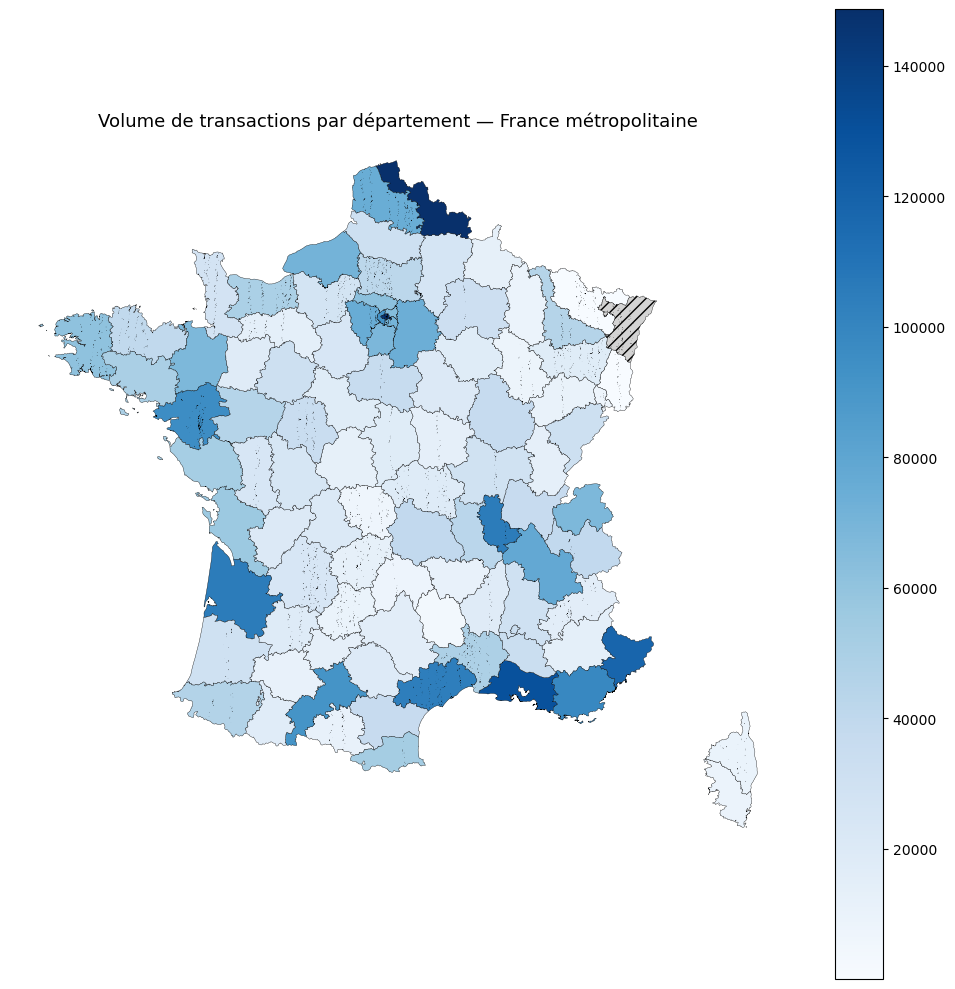

Carte exportée : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\cartographie_temporelle\00_06_cartographie_volume_transactions_france_metropolitaine.png


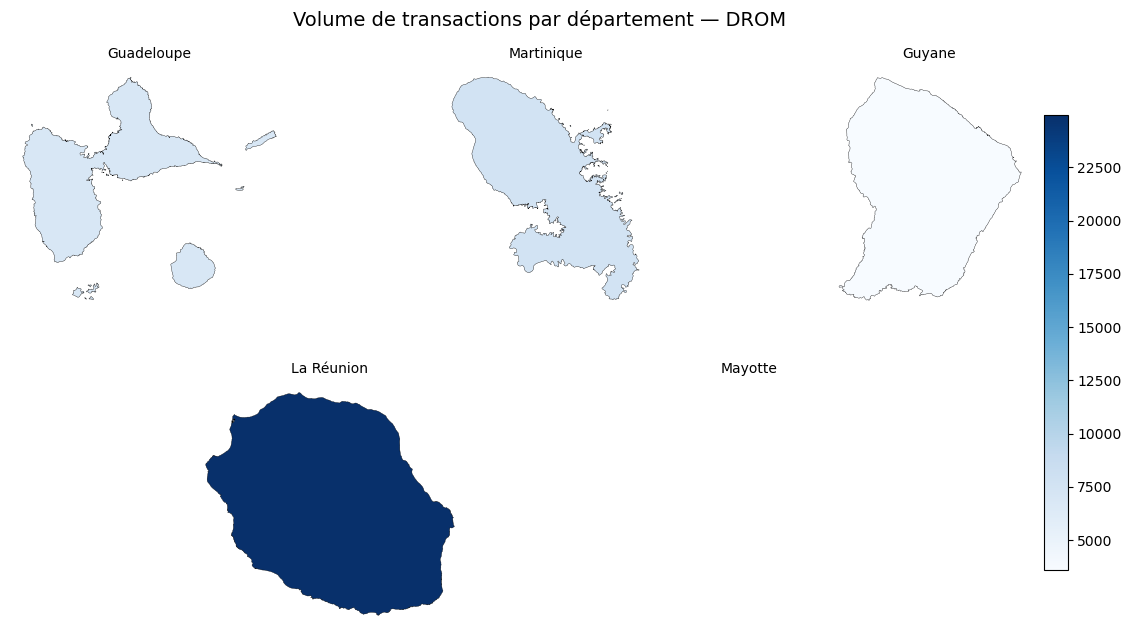

Carte exportée : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\cartographie_temporelle\00_06_cartographie_volume_transactions_drom.png


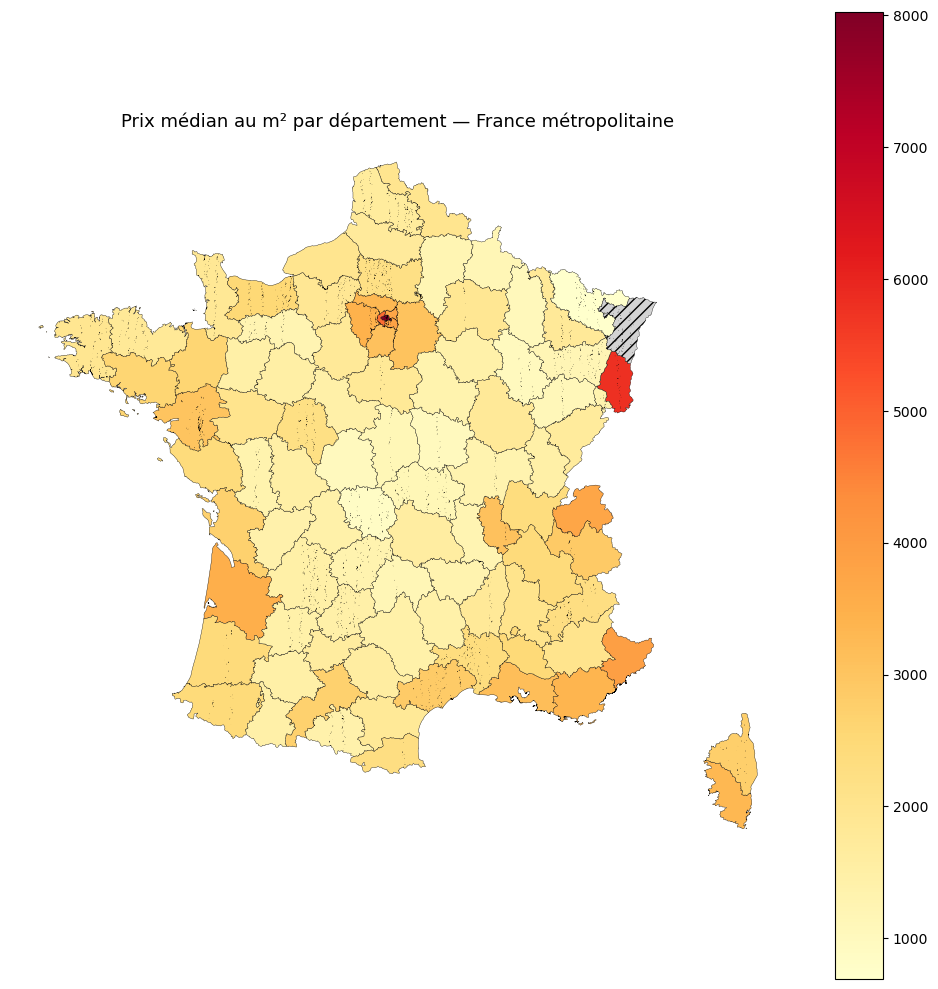

Carte exportée : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\cartographie_temporelle\00_06_cartographie_prix_m2_france_metropolitaine.png


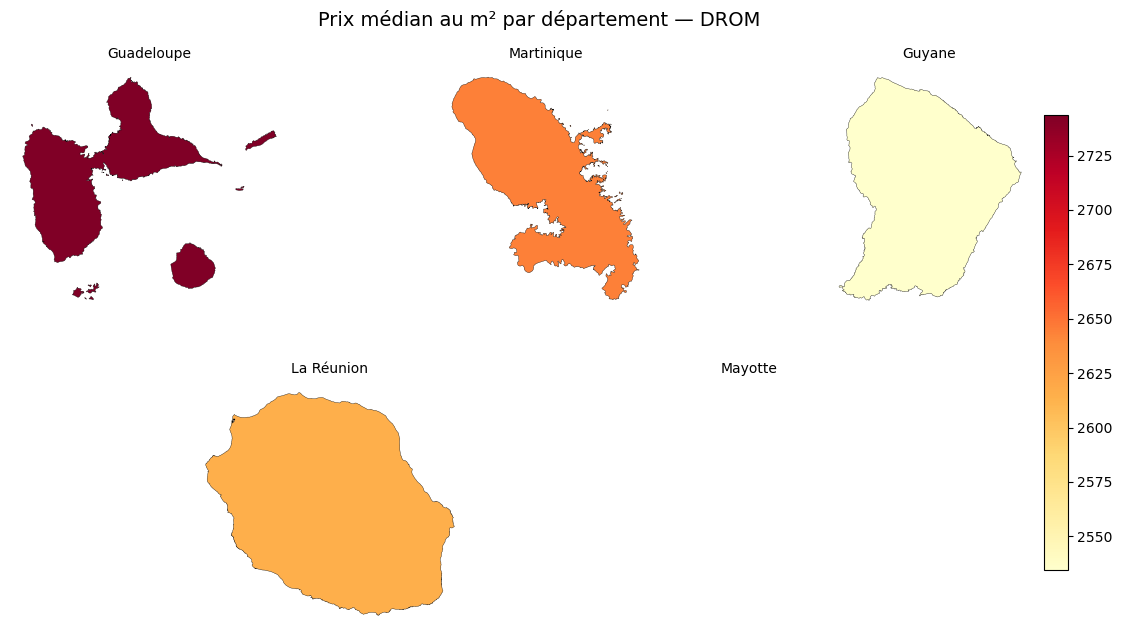

Carte exportée : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\cartographie_temporelle\00_06_cartographie_prix_m2_drom.png
Cartes générées :
- c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\cartographie_temporelle\00_06_cartographie_volume_transactions_france_metropolitaine.png
- c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\cartographie_temporelle\00_06_cartographie_volume_transactions_drom.png
- c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\cartographie_temporelle\00_06_cartographie_prix_m2_france_metropolitaine.png
- c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\figures\cartographie_temporelle\00_06_cartographie_prix_m2_drom.png


In [ ]:

# Cartographie temporelle — logique départementale robuste.
# Les indicateurs temporels restent calculés dans le notebook ; la carte sert ici de contrôle territorial.
# On privilégie un fond départemental existant, puis on complète depuis le fond IRIS uniquement si nécessaire.

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

NOTEBOOK_TAG = "00_06"
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EXTERNAL_DIR = PROJECT_ROOT / "data" / "external"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
MAP_DIR = FIG_DIR / "cartographie_temporelle"
MAP_DIR.mkdir(parents=True, exist_ok=True)

METRO_DEPARTMENT_CODES = [f"{i:02d}" for i in range(1, 96) if i != 20] + ["2A", "2B"]
DROM_DEPARTMENT_CODES = ["971", "972", "973", "974", "976"]
EXPECTED_DEPARTMENT_CODES = METRO_DEPARTMENT_CODES + DROM_DEPARTMENT_CODES


def normalize_code_departement_cartographie(values):
    """Normalise les codes département sans casser 2A, 2B et les DROM."""
    is_scalar = not isinstance(values, (pd.Series, pd.Index, list, tuple, np.ndarray))
    s = pd.Series([values], dtype="string") if is_scalar else pd.Series(values, dtype="string")
    s = (
        s.astype("string")
        .str.strip()
        .str.upper()
        .str.replace(r"\.0$", "", regex=True)
        .str.replace(" ", "", regex=False)
    )
    s = s.mask(s.isin(["", "<NA>", "NAN", "NONE", "NULL"]))
    s = s.where(s.isin(["2A", "2B"]), s.where(s.str.len() >= 3, s.str.zfill(2)))
    return s.iloc[0] if is_scalar else s


def _repair_geometries_cartographie(gdf, label="géométries"):
    """Répare les géométries invalides sans interrompre le notebook."""
    work = gdf.dropna(subset=["geometry"]).copy()
    if work.empty:
        return work

    try:
        invalid_before = int((~work.geometry.is_valid).sum())
    except Exception:
        invalid_before = -1

    if invalid_before not in [0, -1]:
        print(f"Réparation {label} : {invalid_before} géométrie(s) invalide(s).")

    try:
        work["geometry"] = work.geometry.make_valid()
    except Exception:
        try:
            work["geometry"] = work.geometry.buffer(0)
        except Exception as exc:
            print(f"Réparation géométrique partielle impossible pour {label} : {exc}")

    work = work[work.geometry.notna() & ~work.geometry.is_empty].copy()
    return work


def _safe_dissolve_cartographie(gdf, by, label="géométries"):
    """Dissolve robuste, avec secours si une géométrie bloque l'union."""
    work = gdf.dropna(subset=[by, "geometry"]).copy()
    work = _repair_geometries_cartographie(work, label=label)

    if work.empty:
        return gpd.GeoDataFrame(columns=[by, "geometry"], geometry="geometry", crs=getattr(gdf, "crs", None))

    try:
        return work.dissolve(by=by).reset_index()[[by, "geometry"]]
    except Exception as exc:
        print(f"Dissolve standard impossible pour {label} : {exc}")

    try:
        return work.dissolve(by=by, method="unary", grid_size=1).reset_index()[[by, "geometry"]]
    except TypeError:
        pass
    except Exception as exc:
        print(f"Dissolve avec grid_size impossible pour {label} : {exc}")

    rows = []
    try:
        import shapely
    except Exception:
        shapely = None

    for code, part in work.groupby(by):
        geoms = []
        for geom in part.geometry:
            if geom is None or geom.is_empty:
                continue
            try:
                if not geom.is_valid:
                    geom = geom.buffer(0)
            except Exception:
                continue
            if geom is not None and not geom.is_empty:
                geoms.append(geom)

        if not geoms:
            continue

        geom_union = None
        if shapely is not None:
            for grid in [1, 5, 10, 50]:
                try:
                    geom_union = shapely.union_all(geoms, grid_size=grid)
                    break
                except Exception:
                    geom_union = None

        if geom_union is None:
            try:
                geom_union = gpd.GeoSeries(geoms, crs=work.crs).unary_union
            except Exception:
                geom_union = None

        if geom_union is not None and not geom_union.is_empty:
            rows.append({by: code, "geometry": geom_union})

    return gpd.GeoDataFrame(rows, geometry="geometry", crs=work.crs)


def _read_geo_file(path):
    """Lecture géographique locale selon le format."""
    suffix = str(path).lower()
    if suffix.endswith((".shp", ".geojson", ".json", ".gpkg")):
        return gpd.read_file(path)
    if suffix.endswith(".parquet"):
        return gpd.read_parquet(path)
    raise ValueError(f"Format géographique non géré : {path}")


def _detect_department_code_column(gdf):
    """Repère une colonne de code département dans un fond géographique."""
    candidates = [
        "code_departement", "CODE_DEPT", "CODE_DEP", "INSEE_DEP", "INSEE_DEP_CODE",
        "DEP", "DEPT", "CODE", "code", "departement", "DEPARTEMENT",
    ]
    for col in candidates:
        if col in gdf.columns:
            sample = normalize_code_departement_cartographie(gdf[col]).dropna().astype(str)
            if sample.nunique() >= 5:
                return col

    for col in gdf.columns:
        if col == "geometry":
            continue
        sample = normalize_code_departement_cartographie(gdf[col]).dropna().astype(str)
        if sample.empty:
            continue
        valid_rate = sample.str.match(r"^(0[1-9]|[1-8][0-9]|9[0-5]|2A|2B|97[1-6])$").mean()
        if valid_rate > 0.75:
            return col
    return None


def _standardize_department_geometry_columns(gdf, label="fond départemental"):
    """Ramène un fond géographique vers code_departement / nom_departement / geometry."""
    work = gdf.copy()
    if "geometry" not in work.columns or work.empty:
        raise ValueError(f"{label} sans géométrie exploitable.")

    code_col = _detect_department_code_column(work)
    if code_col is None:
        raise ValueError(f"{label} sans colonne code_departement exploitable.")

    nom_col = None
    for candidate in ["nom_departement", "NOM_DEPT", "NOM_DEP", "NOM", "nom", "libelle", "LIBELLE"]:
        if candidate in work.columns:
            nom_col = candidate
            break

    keep = [code_col, "geometry"] + ([nom_col] if nom_col is not None else [])
    work = work[keep].copy().rename(columns={code_col: "code_departement"})
    if nom_col is not None:
        work = work.rename(columns={nom_col: "nom_departement"})
    else:
        work["nom_departement"] = work["code_departement"]

    work["code_departement"] = normalize_code_departement_cartographie(work["code_departement"])
    work = work[work["code_departement"].isin(EXPECTED_DEPARTMENT_CODES)].copy()
    work = _repair_geometries_cartographie(work, label=label)

    if work["code_departement"].duplicated().any():
        names = work[["code_departement", "nom_departement"]].drop_duplicates("code_departement")
        geom = _safe_dissolve_cartographie(work[["code_departement", "geometry"]], by="code_departement", label=label)
        work = geom.merge(names, on="code_departement", how="left")

    return work[["code_departement", "nom_departement", "geometry"]].drop_duplicates(subset=["code_departement"]).copy()


def _candidate_department_files():
    """Cherche les fonds départementaux locaux avant toute reconstruction IRIS."""
    candidates = []
    search_root = EXTERNAL_DIR
    if search_root.exists():
        patterns = [
            "*departement*.shp", "*departements*.shp", "*DEPARTEMENT*.shp", "*DEPARTEMENTS*.shp",
            "*departement*.geojson", "*departements*.geojson", "*DEPARTEMENT*.geojson", "*DEPARTEMENTS*.geojson",
            "*departement*.gpkg", "*departements*.gpkg", "*DEPARTEMENT*.gpkg", "*DEPARTEMENTS*.gpkg",
            "*departement*.parquet", "*departements*.parquet",
        ]
        for pattern in patterns:
            candidates.extend(search_root.rglob(pattern))

    unique = []
    seen = set()
    for path in candidates:
        key = str(path)
        if key not in seen:
            unique.append(path)
            seen.add(key)
    return unique


def _load_department_geometries_from_file():
    """Charge le meilleur fond départemental local disponible."""
    for path in _candidate_department_files():
        if not Path(path).exists():
            continue
        try:
            gdf = _read_geo_file(path)
            gdf = _standardize_department_geometry_columns(gdf, label=f"fond départements {Path(path).name}")
            if not gdf.empty:
                print(f"Fond départemental chargé depuis : {path}")
                return gdf
        except Exception as exc:
            print(f"Fond départemental ignoré ({path}) : {exc}")

    return None


def _candidate_iris_files():
    """Cherche un fond IRIS local utilisé comme solution de secours."""
    if not EXTERNAL_DIR.exists():
        return []

    candidates = []
    for pattern in ["*iris*.shp", "*IRIS*.shp", "*iris*.geojson", "*IRIS*.geojson", "*iris*.gpkg", "*IRIS*.gpkg", "*iris*.parquet", "*IRIS*.parquet"]:
        candidates.extend(EXTERNAL_DIR.rglob(pattern))

    unique = []
    seen = set()
    for path in candidates:
        key = str(path)
        if key not in seen:
            unique.append(path)
            seen.add(key)
    return unique


def _department_geometries_from_iris_fallback():
    """Reconstruit les départements depuis un fond IRIS uniquement si nécessaire."""
    for path in _candidate_iris_files():
        try:
            iris = _read_geo_file(path)
        except Exception:
            continue

        code_col = None
        for candidate in ["code_iris", "CODE_IRIS", "DCOMIRIS", "CODE_IRIS_2021", "IRIS"]:
            if candidate in iris.columns:
                code_col = candidate
                break

        if code_col is None or "geometry" not in iris.columns:
            continue

        try:
            work = iris[[code_col, "geometry"]].copy().rename(columns={code_col: "code_iris"})
            work["code_iris"] = work["code_iris"].astype("string").str.strip().str.zfill(9)
            work["code_departement"] = work["code_iris"].str[:2]
            work.loc[work["code_iris"].str.startswith("97", na=False), "code_departement"] = work["code_iris"].str[:3]
            work["code_departement"] = normalize_code_departement_cartographie(work["code_departement"])
            work = work[work["code_departement"].isin(EXPECTED_DEPARTMENT_CODES)].copy()
            out = _safe_dissolve_cartographie(work, by="code_departement", label=f"IRIS vers départements {Path(path).name}")
            out["nom_departement"] = out["code_departement"]
            if not out.empty:
                print(f"Fond départemental reconstruit depuis le fond IRIS : {path}")
                return out[["code_departement", "nom_departement", "geometry"]]
        except Exception as exc:
            print(f"Reconstruction depuis IRIS ignorée ({path}) : {exc}")

    return None


def load_department_geometries_cartographie():
    """Charge le fond départemental complet, avec complément IRIS si le fond est incomplet."""
    dept = _load_department_geometries_from_file()
    iris_dept = None

    missing_codes = set(EXPECTED_DEPARTMENT_CODES)
    if dept is not None and not dept.empty:
        present_codes = set(dept["code_departement"].dropna().astype(str))
        missing_codes = set(EXPECTED_DEPARTMENT_CODES) - present_codes

    if dept is None or missing_codes:
        iris_dept = _department_geometries_from_iris_fallback()

    if dept is None:
        dept = iris_dept
    elif iris_dept is not None and missing_codes:
        complement = iris_dept[iris_dept["code_departement"].isin(missing_codes)].copy()
        if not complement.empty:
            dept = pd.concat([dept, complement], ignore_index=True)
            dept = gpd.GeoDataFrame(dept, geometry="geometry", crs=dept.crs or iris_dept.crs)
            print(f"Fond départemental complété depuis IRIS : {sorted(complement['code_departement'].astype(str).tolist())}")

    if dept is None or dept.empty:
        raise FileNotFoundError("Aucun fond départemental ou IRIS exploitable trouvé pour la cartographie.")

    dept["code_departement"] = normalize_code_departement_cartographie(dept["code_departement"])
    dept = dept[dept["code_departement"].isin(EXPECTED_DEPARTMENT_CODES)].drop_duplicates(subset=["code_departement"]).copy()
    return dept[["code_departement", "nom_departement", "geometry"]]


def _safe_total_bounds(gdf):
    """Retourne les limites d'une géométrie en évitant les bornes infinies."""
    bounds = gdf.total_bounds
    if not np.isfinite(bounds).all():
        return None
    return bounds


def _plot_single_department_layer(gdf, column, title, output_path, categorical=False, cmap=None):
    """Trace une couche départementale simple avec fond gris pour les valeurs absentes."""
    if gdf.empty:
        return None

    fig, ax = plt.subplots(figsize=(10, 10))

    gdf.plot(
        column=column,
        ax=ax,
        legend=True,
        categorical=categorical,
        cmap=cmap,
        edgecolor="black",
        linewidth=0.25,
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "black",
            "hatch": "///",
            "label": "Sans donnée",
        },
    )

    ax.set_title(title, fontsize=13)
    ax.set_axis_off()

    bounds = _safe_total_bounds(gdf)
    if bounds is not None:
        minx, miny, maxx, maxy = bounds
        marge_x = (maxx - minx) * 0.04 if maxx > minx else 1
        marge_y = (maxy - miny) * 0.04 if maxy > miny else 1
        ax.set_xlim(minx - marge_x, maxx + marge_x)
        ax.set_ylim(miny - marge_y, maxy + marge_y)

    plt.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Carte exportée : {output_path}")
    return output_path


def _plot_drom_facets(gdf, column, title, output_path, categorical=False, cmap=None):
    """Trace les DROM en panneaux séparés pour éviter l'écrasement des emprises."""
    drom_names = {
        "971": "Guadeloupe",
        "972": "Martinique",
        "973": "Guyane",
        "974": "La Réunion",
        "976": "Mayotte",
    }

    gdf_drom = gdf[gdf["code_departement"].isin(DROM_DEPARTMENT_CODES)].copy()
    if gdf_drom.empty:
        return None

    fig = plt.figure(figsize=(12, 7))
    axes = {
        "971": fig.add_axes([0.05, 0.55, 0.25, 0.35]),
        "972": fig.add_axes([0.38, 0.55, 0.25, 0.35]),
        "973": fig.add_axes([0.70, 0.55, 0.25, 0.35]),
        "974": fig.add_axes([0.20, 0.10, 0.25, 0.35]),
        "976": fig.add_axes([0.55, 0.10, 0.25, 0.35]),
    }

    vmin = None
    vmax = None
    if not categorical and column in gdf_drom.columns:
        vmin = gdf_drom[column].min(skipna=True)
        vmax = gdf_drom[column].max(skipna=True)
        if pd.notna(vmin) and pd.notna(vmax) and vmin == vmax:
            vmax = vmin + 1

    for code, ax in axes.items():
        subset = gdf_drom[gdf_drom["code_departement"] == code].copy()
        if not subset.empty:
            subset.plot(
                column=column,
                ax=ax,
                categorical=categorical,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                edgecolor="black",
                linewidth=0.25,
                missing_kwds={
                    "color": "lightgrey",
                    "edgecolor": "black",
                    "hatch": "///",
                    "label": "Sans donnée",
                },
            )
        ax.set_title(drom_names.get(code, code), fontsize=10)
        ax.set_axis_off()

    if not categorical and pd.notna(vmin) and pd.notna(vmax):
        sm = plt.cm.ScalarMappable(cmap=cmap or "viridis", norm=plt.Normalize(vmin=vmin, vmax=vmax))
        sm._A = []
        cbar_ax = fig.add_axes([0.92, 0.18, 0.02, 0.65])
        fig.colorbar(sm, cax=cbar_ax)

    fig.suptitle(f"{title} — DROM", fontsize=14, y=0.98)
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Carte exportée : {output_path}")
    return output_path


def plot_department_map(gdf, column, title, filename, categorical=False, cmap=None):
    """Trace une carte départementale séparée entre métropole et DROM."""
    if gdf is None:
        print("Carte non générée : fond de carte absent.")
        return []

    if column not in gdf.columns:
        print(f"Carte non générée : colonne absente -> {column}")
        return []

    work = gdf.copy()
    work["code_departement"] = normalize_code_departement_cartographie(work["code_departement"])
    work = _repair_geometries_cartographie(work, label=f"carte {column}")

    stem = Path(filename).stem
    suffix = Path(filename).suffix or ".png"
    paths = []

    gdf_metro = work[work["code_departement"].isin(METRO_DEPARTMENT_CODES)].copy()
    if not gdf_metro.empty:
        try:
            gdf_metro = gdf_metro.to_crs(epsg=2154)
        except Exception as exc:
            print(f"Projection Lambert-93 non appliquée pour la métropole : {exc}")

        metro_path = MAP_DIR / f"{stem}_france_metropolitaine{suffix}"
        path = _plot_single_department_layer(
            gdf_metro,
            column=column,
            title=f"{title} — France métropolitaine",
            output_path=metro_path,
            categorical=categorical,
            cmap=cmap,
        )
        if path is not None:
            paths.append(path)

    drom_path = MAP_DIR / f"{stem}_drom{suffix}"
    path = _plot_drom_facets(
        work,
        column=column,
        title=title,
        output_path=drom_path,
        categorical=categorical,
        cmap=cmap,
    )
    if path is not None:
        paths.append(path)

    if not paths:
        print(f"Aucune carte produite pour : {column}")

    return paths


candidates = [
    PROCESSED_DIR / "df_biens_residentiels_temporel.parquet",
    PROCESSED_DIR / "df_biens_residentiels_typologie_marche.parquet",
    PROCESSED_DIR / "df_biens_residentiels_territoire.parquet",
    PROCESSED_DIR / "df_biens_residentiels_iris.parquet",

    # Anciens noms conservés uniquement en secours
    PROCESSED_DIR / "base_modelisation_avec_features_marche_v8_strict_safe.parquet",
    PROCESSED_DIR / "base_modelisation_avec_features_marche_v8.parquet",
    PROCESSED_DIR / "base_modelisation_avec_features_marche_v6_strict_safe.parquet",
    PROCESSED_DIR / "base_modelisation_avec_features_marche_v6.parquet",
    PROCESSED_DIR / "dvf_enrichissement_territorial_v18.parquet",
    PROCESSED_DIR / "dvf_enrichissement_territorial_light_v18.parquet",
]

source_path = next((p for p in candidates if p.exists()), None)
if source_path is None:
    raise FileNotFoundError("Aucun parquet trouvé pour la cartographie.")

df_carto = pd.read_parquet(source_path)

if "prix_m2" not in df_carto.columns and "prix_m2_model" in df_carto.columns:
    df_carto["prix_m2"] = df_carto["prix_m2_model"]

if "code_departement" not in df_carto.columns:
    df_carto["code_departement"] = pd.NA

# Complément depuis le code IRIS si le département n'est pas déjà disponible.
df_carto["code_departement"] = normalize_code_departement_cartographie(df_carto["code_departement"])
if "code_iris" in df_carto.columns:
    missing_dep = df_carto["code_departement"].isna()
    iris_codes = df_carto.loc[missing_dep, "code_iris"].astype("string").str.strip().str.zfill(9)
    dep_from_iris = iris_codes.str[:2]
    dep_from_iris = dep_from_iris.mask(iris_codes.str.startswith("97", na=False), iris_codes.str[:3])
    df_carto.loc[missing_dep, "code_departement"] = normalize_code_departement_cartographie(dep_from_iris)

price_col = "prix_m2" if "prix_m2" in df_carto.columns else None
agg_dict = {"n_transactions": ("code_departement", "size")}
if price_col:
    agg_dict["prix_m2_median"] = (price_col, "median")

agg_dept = (
    df_carto
    .dropna(subset=["code_departement"])
    .groupby("code_departement", as_index=False)
    .agg(**agg_dict)
)
agg_dept["code_departement"] = normalize_code_departement_cartographie(agg_dept["code_departement"])

# Fond départemental maître, complété depuis les IRIS si nécessaire.
dep_geo = load_department_geometries_cartographie()
dep_map = dep_geo.merge(agg_dept, on="code_departement", how="left", validate="1:1")

print(f"Source cartographique : {source_path}")
print(f"Départements dans le fond cartographique : {dep_map['code_departement'].nunique()}")
print(f"Départements avec transactions : {dep_map['n_transactions'].notna().sum()}")

fig_paths = []
fig_paths += plot_department_map(
    dep_map,
    column="n_transactions",
    title="Volume de transactions par département",
    filename=f"{NOTEBOOK_TAG}_cartographie_volume_transactions.png",
    categorical=False,
    cmap="Blues",
)

if "prix_m2_median" in dep_map.columns:
    fig_paths += plot_department_map(
        dep_map,
        column="prix_m2_median",
        title="Prix médian au m² par département",
        filename=f"{NOTEBOOK_TAG}_cartographie_prix_m2.png",
        categorical=False,
        cmap="YlOrRd",
    )

print("Cartes générées :")
for path in fig_paths:
    print("-", path)



<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Rattachement du bloc taux de crédit_B6 — préparation des chemins</h3>  <div style="color: #4b5563; font-size: 14px;">Cette seconde partie enrichit la couche temporelle avec les taux de crédit logement. Les taux apportent une dimension macro-financière utile pour contextualiser la demande immobilière.</div></div>

In [27]:
from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE"
)

DATA_DIR = PROJECT_ROOT / "data"

DATA_PROCESSED = DATA_DIR / "processed"
DATA_EXTERNAL = DATA_DIR / "external"

TAUX_PATH = (
    DATA_EXTERNAL
    / "Taux"
    / "Hist_Taux_Durée_credit logement.csv"
)

OUTPUT_PATH = (
    DATA_PROCESSED
    / "df_biens_residentiels_temporel.parquet"
)

OUTPUT_LIGHT_PATH = (
    DATA_PROCESSED
    / "df_biens_residentiels_temporel_light.parquet"
)

TAUX_FEATURES_PATH = (
    DATA_PROCESSED
    / "df_features_taux_credit_mensuel.parquet"
)

print("Fichier taux :", TAUX_PATH)
print("Existe :", TAUX_PATH.exists())

Fichier taux : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\external\Taux\Hist_Taux_Durée_credit logement.csv
Existe : True


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Chargement de la source externe des taux</h3>  <div style="color: #4b5563; font-size: 14px;">Le fichier externe de taux est lu avec détection souple du séparateur. L’affichage des premières lignes permet de vérifier la structure réelle avant normalisation.</div></div>

In [28]:
assert TAUX_PATH.exists(), f"Fichier des taux introuvable : {TAUX_PATH}"

df_taux_source = pd.read_csv(
    TAUX_PATH,
    sep=None,
    engine="python",
    encoding="utf-8-sig"
)

display(df_taux_source.head())
display(df_taux_source.shape)

,Mois,Taux,Durée,Production
0,juin-20,"1,27","231,3",95
1,juil-20,"1,24","224,2","96,8"
2,août-20,"1,22","230,8","97,6"
3,sept-20,"1,21","231,3",100
4,oct-20,"1,21","235,6",100


(67, 4)

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Normalisation des colonnes de taux</h3>  <div style="color: #4b5563; font-size: 14px;">Les noms de colonnes sont harmonisés pour réduire les risques liés aux accents, espaces ou séparateurs. Cette étape facilite la détection automatique de la période et du taux.</div></div>

In [29]:
df_taux = df_taux_source.copy()

df_taux.columns = (
    df_taux.columns
    .str.strip()
    .str.lower()
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace("/", "_", regex=False)
)

display(pd.DataFrame({"colonnes": df_taux.columns}))
display(df_taux.head())

,colonnes
0,mois
1,taux
2,duree
3,production


,mois,taux,duree,production
0,juin-20,"1,27","231,3",95
1,juil-20,"1,24","224,2","96,8"
2,août-20,"1,22","230,8","97,6"
3,sept-20,"1,21","231,3",100
4,oct-20,"1,21","235,6",100


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Détection des colonnes utiles</h3>  <div style="color: #4b5563; font-size: 14px;">La cellule identifie la colonne de période et la colonne de taux à partir de mots-clés. Les assertions évitent de poursuivre l’analyse si la source ne contient pas les champs attendus.</div></div>

In [30]:
date_candidates = [
    c for c in df_taux.columns
    if any(k in c for k in ["mois", "date", "periode", "annee"])
]

rate_candidates = [
    c for c in df_taux.columns
    if any(k in c for k in ["taux", "tx"])
]

assert date_candidates, "Aucune colonne de période détectée dans le fichier des taux."
assert rate_candidates, "Aucune colonne de taux détectée dans le fichier des taux."

DATE_COL_TAUX = date_candidates[0]
TAUX_COL = rate_candidates[0]

print("Colonne période retenue :", DATE_COL_TAUX)
print("Colonne taux retenue :", TAUX_COL)
display(df_taux[[DATE_COL_TAUX, TAUX_COL]].head())

Colonne période retenue : mois
Colonne taux retenue : taux


,mois,taux
0,juin-20,"1,27"
1,juil-20,"1,24"
2,août-20,"1,22"
3,sept-20,"1,21"
4,oct-20,"1,21"


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Conversion des périodes mensuelles</h3>  <div style="color: #4b5563; font-size: 14px;">Les mois rédigés en français sont convertis en dates mensuelles normalisées. Cette transformation rend possible la jointure avec les transactions agrégées au format année-mois.</div></div>

In [31]:
mois_fr = {
    "janv": "01",
    "janvier": "01",
    "fev": "02",
    "fevr": "02",
    "fevrier": "02",
    "févr": "02",
    "février": "02",
    "mars": "03",
    "avr": "04",
    "avril": "04",
    "mai": "05",
    "juin": "06",
    "juil": "07",
    "juillet": "07",
    "aout": "08",
    "août": "08",
    "sept": "09",
    "septembre": "09",
    "oct": "10",
    "octobre": "10",
    "nov": "11",
    "novembre": "11",
    "dec": "12",
    "déc": "12",
    "decembre": "12",
    "décembre": "12",
}

df_taux["periode_source"] = (
    df_taux[DATE_COL_TAUX]
    .astype("string")
    .str.lower()
    .str.strip()
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
)

# Gestion des séparateurs possibles : juin-20, juin 20, juin_20.
periode_split = df_taux["periode_source"].str.replace("_", "-", regex=False).str.replace(" ", "-", regex=False).str.split("-", expand=True)

df_taux["mois_txt"] = periode_split[0].str.strip()
df_taux["annee_txt"] = periode_split[1].str.strip()

df_taux["mois_num"] = df_taux["mois_txt"].map(mois_fr)

df_taux["annee_num"] = df_taux["annee_txt"].astype("string").str.extract(r"(\d{2,4})")[0]
df_taux["annee_num"] = np.where(
    df_taux["annee_num"].str.len() == 2,
    "20" + df_taux["annee_num"],
    df_taux["annee_num"]
)

df_taux["date_taux"] = pd.to_datetime(
    df_taux["annee_num"].astype("string")
    + "-"
    + df_taux["mois_num"].astype("string")
    + "-01",
    errors="coerce"
)

df_taux["annee_mois"] = df_taux["date_taux"].dt.to_period("M").astype("string")

controle_dates_taux = pd.DataFrame({
    "periode_source": df_taux[DATE_COL_TAUX],
    "mois_txt": df_taux["mois_txt"],
    "annee_txt": df_taux["annee_txt"],
    "date_taux": df_taux["date_taux"],
    "annee_mois": df_taux["annee_mois"],
})

display(controle_dates_taux.head(12))
print("Dates valides :", round(df_taux["date_taux"].notna().mean() * 100, 1), "%")

assert df_taux["date_taux"].notna().mean() > 0.90, "La conversion des dates du fichier de taux est insuffisante."

,periode_source,mois_txt,annee_txt,date_taux,annee_mois
0,juin-20,juin,20,2020-06-01,2020-06
1,juil-20,juil,20,2020-07-01,2020-07
2,août-20,aout,20,2020-08-01,2020-08
3,sept-20,sept,20,2020-09-01,2020-09
4,oct-20,oct,20,2020-10-01,2020-10
5,nov-20,nov,20,2020-11-01,2020-11
6,déc-20,dec,20,2020-12-01,2020-12
7,janv-21,janv,21,2021-01-01,2021-01
8,févr-21,fevr,21,2021-02-01,2021-02
9,mars-21,mars,21,2021-03-01,2021-03


Dates valides : 100.0 %


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Conversion numérique des taux</h3>  <div style="color: #4b5563; font-size: 14px;">Les taux sont convertis en valeurs numériques après remplacement des virgules décimales. Le contrôle de validité sécurise l’exploitation statistique de la série.</div></div>

In [32]:
df_taux["taux_credit_moyen"] = (
    df_taux[TAUX_COL]
    .astype("string")
    .str.replace(",", ".", regex=False)
    .str.replace("%", "", regex=False)
    .str.strip()
)

df_taux["taux_credit_moyen"] = pd.to_numeric(
    df_taux["taux_credit_moyen"],
    errors="coerce"
)

display(df_taux[[DATE_COL_TAUX, TAUX_COL, "annee_mois", "taux_credit_moyen"]].head(12))
print("Taux valides :", round(df_taux["taux_credit_moyen"].notna().mean() * 100, 1), "%")

assert df_taux["taux_credit_moyen"].notna().mean() > 0.90, "La conversion numérique des taux est insuffisante."

,mois,taux,annee_mois,taux_credit_moyen
0,juin-20,"1,27",2020-06,1.27
1,juil-20,"1,24",2020-07,1.24
2,août-20,"1,22",2020-08,1.22
3,sept-20,"1,21",2020-09,1.21
4,oct-20,"1,21",2020-10,1.21
5,nov-20,"1,19",2020-11,1.19
6,déc-20,"1,17",2020-12,1.17
7,janv-21,"1,13",2021-01,1.13
8,févr-21,"1,1",2021-02,1.1
9,mars-21,"1,08",2021-03,1.08


Taux valides : 100.0 %


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Agrégation mensuelle des taux</h3>  <div style="color: #4b5563; font-size: 14px;">Les observations de taux sont consolidées au mois. La table résultante devient une série macro-financière alignable avec les périodes DVF.</div></div>

In [33]:
df_taux_mensuel = (
    df_taux
    .dropna(subset=["annee_mois", "taux_credit_moyen"])
    .groupby("annee_mois", as_index=False)
    .agg(taux_credit_moyen=("taux_credit_moyen", "mean"))
    .sort_values("annee_mois")
    .reset_index(drop=True)
)

display(df_taux_mensuel.head())
display(df_taux_mensuel.tail())

assert len(df_taux_mensuel) > 1, "L'agrégation des taux ne contient qu'une seule période : vérifier la colonne de date."
assert not (df_taux_mensuel["annee_mois"].astype(str) == "NaT").any(), "La période NaT subsiste dans les taux mensuels."

,annee_mois,taux_credit_moyen
0,2020-06,1.27
1,2020-07,1.24
2,2020-08,1.22
3,2020-09,1.21
4,2020-10,1.21


,annee_mois,taux_credit_moyen
62,2025-08,3.06
63,2025-09,3.11
64,2025-10,3.13
65,2025-11,3.13
66,2025-12,3.16


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Création des features de taux</h3>  <div style="color: #4b5563; font-size: 14px;">Les variations, moyennes mobiles, retards et score de tension crédit décrivent le niveau et la dynamique récente des conditions de financement.</div></div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Objectif de cette étape</h3>  <div style="color: #4b5563; font-size: 14px;">Cette cellule enrichit la série temporelle des taux de crédit afin de transformer : une simple série brute de taux ; en variables explicatives exploitables par le pipeline de modélisation. L’idée est de capturer plusieurs dimensions : niveau des taux ; vitesse de variation ; tendance récente ; inertie ; tension financière. Ces variables permettront ensuite : d’expliquer les cycles immobiliers ; de mesurer l’impact du crédit sur les prix et les volumes ; et potentiellement d’anticiper des retournements de marché.</div></div>

In [34]:
df_taux_mensuel["variation_taux_1m"] = df_taux_mensuel["taux_credit_moyen"].diff(1)
df_taux_mensuel["variation_taux_3m"] = df_taux_mensuel["taux_credit_moyen"].diff(3)

df_taux_mensuel["taux_credit_roll3"] = (
    df_taux_mensuel["taux_credit_moyen"]
    .rolling(window=3, min_periods=1)
    .mean()
)

df_taux_mensuel["taux_credit_lag1"] = df_taux_mensuel["taux_credit_moyen"].shift(1)
df_taux_mensuel["taux_credit_lag3"] = df_taux_mensuel["taux_credit_moyen"].shift(3)

moyenne_taux = df_taux_mensuel["taux_credit_moyen"].mean()
ecart_type_taux = df_taux_mensuel["taux_credit_moyen"].std()

df_taux_mensuel["score_tension_credit"] = (
    (df_taux_mensuel["taux_credit_moyen"] - moyenne_taux) / ecart_type_taux
)

display(df_taux_mensuel.head(10))

,annee_mois,taux_credit_moyen,variation_taux_1m,variation_taux_3m,taux_credit_roll3,taux_credit_lag1,taux_credit_lag3,score_tension_credit
0,2020-06,1.27,<NA>,<NA>,1.270000,<NA>,<NA>,-1.048253
1,2020-07,1.24,-0.03,<NA>,1.255000,1.27,<NA>,-1.074776
2,2020-08,1.22,-0.02,<NA>,1.243333,1.24,<NA>,-1.092458
3,2020-09,1.21,-0.01,-0.06,1.223333,1.22,1.27,-1.101299
4,2020-10,1.21,0.0,-0.03,1.213333,1.21,1.24,-1.101299
5,2020-11,1.19,-0.02,-0.03,1.203333,1.21,1.22,-1.118981
6,2020-12,1.17,-0.02,-0.04,1.190000,1.19,1.21,-1.136664
7,2021-01,1.13,-0.04,-0.08,1.163333,1.17,1.21,-1.172028
8,2021-02,1.1,-0.03,-0.09,1.133333,1.13,1.19,-1.198551
9,2021-03,1.08,-0.02,-0.09,1.103333,1.1,1.17,-1.216233


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture du niveau des taux</h3>  <div style="color: #4b5563; font-size: 14px;">Le graphique du taux moyen montre le contexte de financement dans lequel les transactions se réalisent. Il ne mesure pas directement la solvabilité, mais donne un signal de contrainte macro-financière.</div></div>

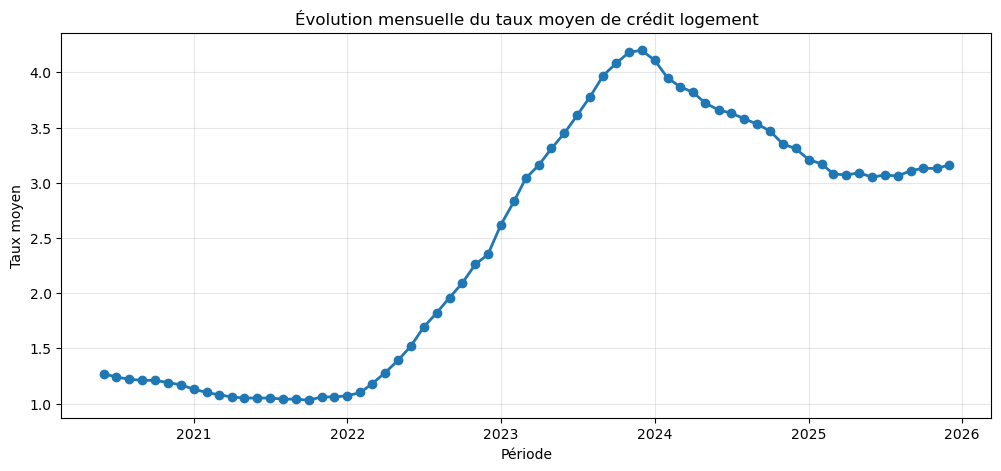

In [35]:
df_taux_plot = df_taux_mensuel.copy()

df_taux_plot["date_mois"] = pd.to_datetime(
    df_taux_plot["annee_mois"].astype(str) + "-01",
    errors="coerce"
)

df_taux_plot = df_taux_plot.dropna(subset=["date_mois", "taux_credit_moyen"]).copy()

plt.figure(figsize=(12, 5))
plt.plot(
    df_taux_plot["date_mois"],
    df_taux_plot["taux_credit_moyen"],
    marker="o",
    linewidth=2
)
plt.title("Évolution mensuelle du taux moyen de crédit logement")
plt.xlabel("Période")
plt.ylabel("Taux moyen")
plt.grid(True, alpha=0.3)
plt.show()

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Évolution du taux moyen des crédits immobiliers</h3>  <div style="color: #4b5563; font-size: 14px;">Ce graphique met en évidence le changement rapide du contexte de financement immobilier entre 2020 et 2025. Trois phases principales apparaissent : une période de taux historiquement bas ; une forte remontée entre 2022 et 2023 ; puis une phase de stabilisation à un niveau plus élevé. Entre 2020 et 2021, les taux évoluent autour de 1 %, dans un environnement monétaire très favorable. Cette période soutient fortement : la solvabilité des ménages ; les volumes de transactions ; et la hausse des prix immobiliers. À partir de 2022, la remontée des taux est particulièrement rapide, avec un passage au-dessus de 4 % en moins de deux ans. Cette rupture reflète : le resserrement monétaire ; la lutte contre l’inflation ; et le durcissement des conditions de crédit. L’impact sur le marché immobilier est majeur : baisse de la capacité d’emprunt ; contraction des volumes ; ralentissement du marché ; et hausse de la sélectivité bancaire. Depuis 2024, les taux amorcent une détente progressive mais restent nettement supérieurs aux niveaux observés avant 2022. Le marché semble ainsi entrer dans un nouveau régime de financement, plus contraint et moins favorable à une expansion rapide de l’activité. Cette dynamique explique en grande partie les signaux observés dans le pipeline temporel : ralentissement des transactions ; volatilité accrue ; affaiblissement du momentum ; et différenciation plus forte entre marchés tendus et marchés détendus. Les variables dérivées construites à partir des taux constituent donc un enrichissement macroéconomique important pour la modélisation temporelle du marché immobilier.</div></div>

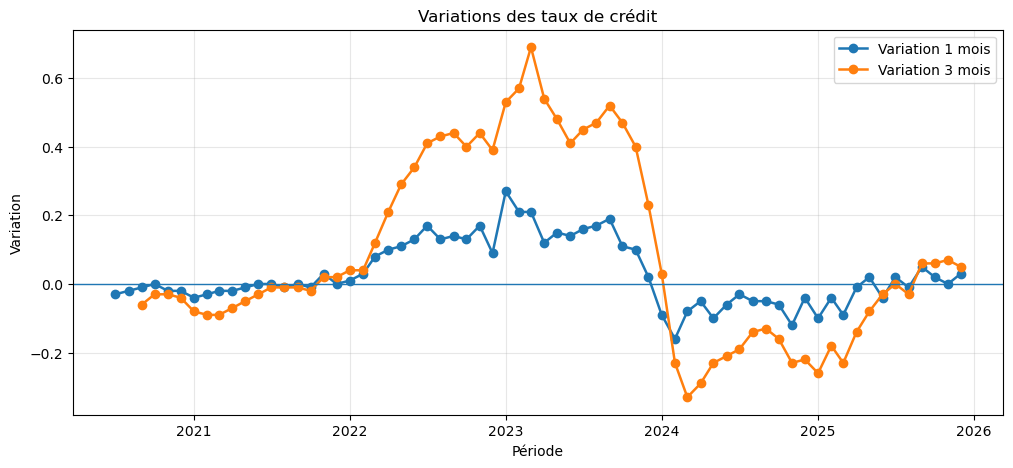

In [36]:
plt.figure(figsize=(12, 5))
plt.plot(
    df_taux_plot["date_mois"],
    df_taux_mensuel.loc[df_taux_plot.index, "variation_taux_1m"],
    marker="o",
    linewidth=1.8,
    label="Variation 1 mois"
)
plt.plot(
    df_taux_plot["date_mois"],
    df_taux_mensuel.loc[df_taux_plot.index, "variation_taux_3m"],
    marker="o",
    linewidth=1.8,
    label="Variation 3 mois"
)
plt.axhline(0, linewidth=1)
plt.title("Variations des taux de crédit")
plt.xlabel("Période")
plt.ylabel("Variation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Variations des taux de crédit</h3>  <div style="color: #4b5563; font-size: 14px;">La courbe mensuelle reflète les ajustements immédiats des conditions de financement, tandis que la variation sur 3 mois met davantage en évidence les tendances de fond du cycle monétaire. Entre 2020 et 2021, les variations restent faibles et proches de zéro, traduisant un environnement de taux historiquement stable et favorable au financement immobilier. À partir de 2022, le graphique met en évidence une accélération très brutale des hausses de taux. La dynamique cumulée sur 3 mois atteint des niveaux exceptionnellement élevés, signe d’un resserrement monétaire rapide et d’une forte dégradation des conditions de crédit. Cette phase correspond au principal point de rupture du cycle immobilier récent : baisse de solvabilité des ménages ; contraction des volumes de transactions ; ralentissement du marché ; et montée de la sélectivité bancaire. À partir de 2024, les variations deviennent progressivement négatives, indiquant une phase de détente relative. Les taux restent toutefois élevés en niveau, ce qui suggère davantage une stabilisation qu’un retour au régime de crédit observé avant 2022. En fin de période, les variations reviennent proches de zéro, traduisant un nouvel équilibre du marché du financement immobilier. Ces indicateurs sont particulièrement utiles pour la modélisation temporelle car les volumes immobiliers réagissent généralement plus rapidement aux variations de crédit que les prix eux-mêmes. Les dynamiques de taux constituent ainsi un signal avancé important des changements de régime du marché immobilier.</div></div>

In [ ]:
# Liste des dataframes candidats pouvant servir de base transactionnelle temporelle.
# L’objectif est de rendre la cellule robuste aux différences de noms
# entre versions du notebook.
candidate_temporal_dfs = [
    "df_biens_residentiels_temporel",
    "base_time",
    "df_modelisation_temporelle",
    "df_temporel",
    "df",
]

# Recherche du premier dataframe disponible dans l’environnement.
# On vérifie à la fois :
# - que le nom existe dans globals() ;
# - et que l’objet est bien un DataFrame pandas.
temporal_df_name = next(
    (
        name
        for name in candidate_temporal_dfs
        if name in globals()
        and isinstance(globals()[name], pd.DataFrame)
    ),
    None
)

# Sécurité : arrêt explicite si aucune base temporelle n’est disponible.
assert (
    temporal_df_name is not None
), "Aucun dataframe temporel disponible pour la jointure des taux."

# Copie de travail de la base retenue.
# On évite de modifier directement l’objet source.
df_biens_residentiels_temporel = globals()[temporal_df_name].copy()

# Construction ou normalisation de la clé mensuelle annee_mois.
# Cette clé permet de rattacher les variables de taux,
# disponibles à fréquence mensuelle.
if "annee_mois" not in df_biens_residentiels_temporel.columns:

    # Recherche d’une colonne date disponible.
    date_cols = [
        c for c in df_biens_residentiels_temporel.columns
        if "date" in c.lower()
    ]

    assert (
        len(date_cols) > 0
    ), "Aucune colonne date disponible pour construire annee_mois."

    # Conversion de la première colonne date détectée
    # en période mensuelle au format chaîne.
    df_biens_residentiels_temporel["annee_mois"] = (
        pd.to_datetime(
            df_biens_residentiels_temporel[date_cols[0]],
            errors="coerce"
        )
        .dt.to_period("M")
        .astype("string")
    )

else:
    # Si la clé existe déjà, on harmonise son type.
    df_biens_residentiels_temporel["annee_mois"] = (
        df_biens_residentiels_temporel["annee_mois"]
        .astype("string")
    )

# Variables de taux à rattacher à la base transactionnelle.
# Elles décrivent :
# - le niveau des taux ;
# - leurs variations ;
# - leurs tendances ;
# - et un score synthétique de tension crédit.
features_taux = [
    "annee_mois",
    "taux_credit_moyen",
    "variation_taux_1m",
    "variation_taux_3m",
    "taux_credit_roll3",
    "taux_credit_lag1",
    "taux_credit_lag3",
    "score_tension_credit",
]

# Suppression préventive des anciennes colonnes de taux
# si la cellule a déjà été exécutée.
# Cela évite la création de suffixes _x / _y après la jointure.
cols_taux_existantes = [
    c for c in features_taux
    if c != "annee_mois"
    and c in df_biens_residentiels_temporel.columns
]

df_biens_residentiels_temporel = (
    df_biens_residentiels_temporel
    .drop(columns=cols_taux_existantes, errors="ignore")
)

# Jointure des variables de taux sur la clé mensuelle.
# how="left" conserve toutes les transactions immobilières.
# validate="many_to_one" vérifie que plusieurs transactions
# peuvent correspondre à un seul mois de taux.
df_biens_residentiels_temporel = (
    df_biens_residentiels_temporel
    .merge(
        df_taux_mensuel[features_taux],
        on="annee_mois",
        how="left",
        validate="many_to_one"
    )
)

# Contrôle visuel des variables de taux rattachées.
display(
    df_biens_residentiels_temporel[features_taux].head()
)

# Contrôle du taux de valeurs manquantes après jointure.
# Un taux élevé indiquerait un problème de couverture temporelle
# ou une incohérence de format sur annee_mois.
display(
    df_biens_residentiels_temporel[
        [col for col in features_taux if col != "annee_mois"]
    ]
    .isna()
    .mean()
    .sort_values()
    .to_frame("part_valeurs_manquantes")
)

,annee_mois,taux_credit_moyen,variation_taux_1m,variation_taux_3m,taux_credit_roll3,taux_credit_lag1,taux_credit_lag3,score_tension_credit
0,2021-01,1.13,-0.04,-0.08,1.163333,1.17,1.21,-1.172028
1,2021-01,1.13,-0.04,-0.08,1.163333,1.17,1.21,-1.172028
2,2021-04,1.06,-0.02,-0.07,1.080000,1.08,1.13,-1.233915
3,2021-03,1.08,-0.02,-0.09,1.103333,1.1,1.17,-1.216233
4,2021-12,1.06,0.0,0.02,1.050000,1.06,1.04,-1.233915


,part_valeurs_manquantes
taux_credit_moyen,0.0
variation_taux_1m,0.0
variation_taux_3m,0.0
taux_credit_roll3,0.0
taux_credit_lag1,0.0
taux_credit_lag3,0.0
score_tension_credit,0.0


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Export final de la base temporelle enrichie</h3>  <div style="color: #4b5563; font-size: 14px;">La base complète et une version allégée sont exportées. Elles constituent la sortie opérationnelle du notebook pour les étapes suivantes du pipeline.</div></div>

In [38]:
df_biens_residentiels_temporel.to_parquet(OUTPUT_PATH, index=False)

colonnes_light_candidates = [
    "id_mutation",
    "date_mutation",
    "annee",
    "trimestre",
    "mois",
    "annee_mois",
    "prix_m2",
    "code_commune",
    "code_iris",
    "type_bien",
    "taux_credit_moyen",
    "variation_taux_1m",
    "variation_taux_3m",
    "taux_credit_roll3",
    "taux_credit_lag1",
    "taux_credit_lag3",
    "score_tension_credit",
]

colonnes_light = [
    col for col in colonnes_light_candidates
    if col in df_biens_residentiels_temporel.columns
]

if len(colonnes_light) > 0:
    df_biens_residentiels_temporel_light = df_biens_residentiels_temporel[colonnes_light].copy()
    df_biens_residentiels_temporel_light.to_parquet(OUTPUT_LIGHT_PATH, index=False)

df_taux_mensuel.to_parquet(TAUX_FEATURES_PATH, index=False)

print(f"Base temporelle enrichie exportée : {OUTPUT_PATH}")
if OUTPUT_LIGHT_PATH.exists():
    print(f"Base temporelle allégée exportée : {OUTPUT_LIGHT_PATH}")
print(f"Features de taux exportées : {TAUX_FEATURES_PATH}")

Base temporelle enrichie exportée : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_temporel.parquet
Base temporelle allégée exportée : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_biens_residentiels_temporel_light.parquet
Features de taux exportées : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_features_taux_credit_mensuel.parquet


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Limites méthodologiques</h3>  <div style="color: #4b5563; font-size: 14px;">Les indicateurs temporels restent sensibles à l’horizon observé, aux volumes mensuels et aux ruptures de marché. Ils décrivent des dynamiques agrégées et ne doivent pas être interprétés comme des causalités directes au niveau d’un bien isolé. Synthèse du notebook 07 Le notebook produit une couche temporelle exploitable pour l’analyse métier et la modélisation : série mensuelle, phases de marché, scores, variables retardées et contexte de taux. La sortie transmise au notebook suivant est une base résidentielle enrichie par des signaux temporels interprétables et contrôlés contre la fuite d’information.</div></div>